[Mohit Saharan](https://linkedin.com/in/msaharan), 20260505, P17

Apache 2.0 License (see github.com/msaharan/dsaiengineering/LICENSE)

# Hardening a TabPFN and TabICL embedding workflow for fraud detection

This notebook is the next iteration of the TabPFN/TabICL fraud-embedding workflow. It keeps the same production-style question: can offline row embeddings from TabPFN or TabICL improve a classical XGBoost fraud scorer? The May 5 version focuses less on adding another model and more on making the evaluation protocol more reusable: stronger chronological tuning data, explicit calibration-base rows, quantile reliability diagnostics, and CSV artifacts for every key table.


## How to run this notebook on Kaggle

1. Import this notebook into Kaggle.
2. Enable GPU acceleration.
3. Turn on Internet access because the notebook downloads packages, cuDF, model checkpoints, and the public fraud CSV.
4. Add a Kaggle secret named `TABPFN_TOKEN` for local TabPFN weights after accepting the Prior Labs license.
5. Optionally add `HF_TOKEN` for Hugging Face downloads. TabICL is usually downloadable without it, but using a token can avoid rate-limit issues.

This notebook assumes a CUDA GPU runtime. The setup cell installs `cudf-cu12` from NVIDIA's package index, and the imports cell enables the cuDF pandas accelerator before importing pandas. TabPFN and TabICL generate embeddings on CUDA devices; the downstream scorer remains classical XGBoost by default.

The default May 5 configuration tunes the fair raw-vs-embedding comparison on the full train-plus-validation history after the TFM context window. This is slower than the May 4 sampled-tuning path, but it usually gives more valid chronological tuning folds under severe class imbalance. Set `USE_FULL_PREHOLDOUT_TUNING_FOR_FAIR_COMPARISON = False` for a faster exploratory rerun.

The notebook writes key tables and figures to `tabpfn_tabicl_fraud_detection_20260505_outputs/`. Treat displayed notebook output as a convenience view; the CSV artifacts are the reviewable run record.


In [1]:
%%time
# Kaggle / Colab setup.
# Run this cell once. If imports still fail, restart the notebook session and continue below.

import subprocess
import sys

PYPI_PACKAGES = [
    "xgboost>=2.0.0",
    "rich",
    "openml",
    "tabpfn",
    "tabicl",
    "cupy-cuda12x",
]

subprocess.run([sys.executable, "-m", "pip", "install", "-q", *PYPI_PACKAGES], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--extra-index-url", "https://pypi.nvidia.com", "cudf-cu12"], check=True)


CPU times: user 947 µs, sys: 993 µs, total: 1.94 ms
Wall time: 7 s


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', '--extra-index-url', 'https://pypi.nvidia.com', 'cudf-cu12'], returncode=0)

## 0. Imports, Secrets, and Configuration

In [2]:
import importlib.metadata as importlib_metadata
import os
from pathlib import Path
import platform
import time
import warnings
from traceback import format_exception_only

import cudf.pandas
cudf.pandas.install()

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch

from IPython.display import display
from rich.console import Console
from scipy.stats import loguniform, randint, uniform

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

from xgboost import XGBClassifier

warnings.filterwarnings(
    "ignore",
    message="The `cv='prefit'` option is deprecated",
    category=FutureWarning,
)

console = Console()
console.print("[green]cuDF pandas accelerator enabled.[/green]")

SEED = 42
N_TFM_ESTIMATORS = 8
CLASSICAL_TUNING_ITERATIONS = 32
CLASSICAL_TUNING_JOBS = 1
CLASSICAL_TUNING_CV_SPLITS = 5
MIN_TUNING_TRAIN_FRAUD_ROWS = 10
MIN_TUNING_VALIDATION_FRAUD_ROWS = 5
TUNE_CLASSICAL_MODELS = True
RUN_LOGISTIC_REGRESSION_CPU_BENCHMARK = False
USE_FULL_PREHOLDOUT_TUNING_FOR_FAIR_COMPARISON = True

EMBEDDING_CONTEXT_END_FRACTION_BY_TIME = 0.20
TRAIN_END_FRACTION_BY_TIME = 0.60
VALIDATION_END_FRACTION_BY_TIME = 0.70
CALIBRATION_END_FRACTION_BY_TIME = 0.80

MAX_TRAIN_NORMAL = 4000
MAX_CONTEXT_NORMAL = 4000
MAX_TEST_NORMAL = 20000
USE_TIME_AS_FEATURE = False
BUILD_FULL_HOLDOUT_EMBEDDINGS = True
TFM_EMBEDDING_CHUNK_SIZE = 4096

XGBOOST_TREE_METHOD = "hist"
XGBOOST_DEVICE = "cuda"
PR_CURVE_MAX_MODELS = 12
RUNTIME_PLOT_MAX_MODELS = 12
CALIBRATION_PLOT_MAX_MODELS = 8

ARTIFACT_DIR = Path("tabpfn_tabicl_fraud_detection_20260505_outputs")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def save_artifact_table(table, filename, index=False):
    output_path = ARTIFACT_DIR / filename
    table.to_csv(output_path, index=index)
    print(f"Saved {output_path}")
    return output_path


np.random.seed(SEED)

CUDA_DEVICE_COUNT = torch.cuda.device_count()
if CUDA_DEVICE_COUNT < 1:
    raise RuntimeError("This notebook requires a CUDA GPU runtime.")

TABICL_DEVICE = "cuda:0"
TABPFN_DEVICE = [f"cuda:{i}" for i in range(CUDA_DEVICE_COUNT)]


def installed_version(*package_names):
    for package_name in package_names:
        try:
            return importlib_metadata.version(package_name)
        except importlib_metadata.PackageNotFoundError:
            continue
    return "not installed"


environment_summary = pd.DataFrame(
    [
        {"Component": "Python", "Version": platform.python_version()},
        {"Component": "CUDA devices", "Version": CUDA_DEVICE_COUNT},
        {"Component": "pandas", "Version": installed_version("pandas")},
        {"Component": "cudf", "Version": installed_version("cudf", "cudf-cu12")},
        {"Component": "cupy", "Version": cp.__version__},
        {"Component": "numpy", "Version": installed_version("numpy")},
        {"Component": "scikit-learn", "Version": sklearn.__version__},
        {"Component": "xgboost", "Version": installed_version("xgboost")},
        {"Component": "torch", "Version": torch.__version__},
        {"Component": "tabpfn", "Version": installed_version("tabpfn")},
        {"Component": "tabicl", "Version": installed_version("tabicl")},
    ]
)

display(environment_summary)
save_artifact_table(environment_summary, "environment_summary.csv")
print(f"TabICL device: {TABICL_DEVICE}")
print(f"TabPFN device: {TABPFN_DEVICE}")
print(f"TFM ensemble members: {N_TFM_ESTIMATORS}")
print(f"Tune classical models: {TUNE_CLASSICAL_MODELS}")
print(f"Classical tuning iterations per model: {CLASSICAL_TUNING_ITERATIONS}")
print(f"Classical chronological tuning folds requested: {CLASSICAL_TUNING_CV_SPLITS}")
print(f"Minimum fraud rows per tuning fold: train={MIN_TUNING_TRAIN_FRAUD_ROWS}, validation={MIN_TUNING_VALIDATION_FRAUD_ROWS}")
print(f"Run CPU Logistic Regression benchmark: {RUN_LOGISTIC_REGRESSION_CPU_BENCHMARK}")
print(f"Use full pre-holdout tuning for fair comparison: {USE_FULL_PREHOLDOUT_TUNING_FOR_FAIR_COMPARISON}")
print(f"XGBoost device: {XGBOOST_DEVICE}")
print(f"Embedding context/train/validation/calibration/test time fractions: 0-{EMBEDDING_CONTEXT_END_FRACTION_BY_TIME:.0%}, {EMBEDDING_CONTEXT_END_FRACTION_BY_TIME:.0%}-{TRAIN_END_FRACTION_BY_TIME:.0%}, {TRAIN_END_FRACTION_BY_TIME:.0%}-{VALIDATION_END_FRACTION_BY_TIME:.0%}, {VALIDATION_END_FRACTION_BY_TIME:.0%}-{CALIBRATION_END_FRACTION_BY_TIME:.0%}, {CALIBRATION_END_FRACTION_BY_TIME:.0%}-100%")
print(f"Use Time as model feature: {USE_TIME_AS_FEATURE}")
print(f"Build full-holdout embedding features: {BUILD_FULL_HOLDOUT_EMBEDDINGS}")


cuDF pandas accelerator enabled.

,Component,Version
0,Python,3.12.12
1,CUDA devices,2
2,pandas,2.3.3
3,cudf,26.2.1
4,cupy,14.0.1
5,numpy,2.0.2
6,scikit-learn,1.6.1
7,xgboost,3.2.0
8,torch,2.10.0+cu128
9,tabpfn,7.1.1


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/environment_summary.csv
TabICL device: cuda:0
TabPFN device: ['cuda:0', 'cuda:1']
TFM ensemble members: 8
Tune classical models: True
Classical tuning iterations per model: 32
Classical chronological tuning folds requested: 5
Minimum fraud rows per tuning fold: train=10, validation=5
Run CPU Logistic Regression benchmark: False
Use full pre-holdout tuning for fair comparison: True
XGBoost device: cuda
Embedding context/train/validation/calibration/test time fractions: 0-20%, 20%-60%, 60%-70%, 70%-80%, 80%-100%
Use Time as model feature: False
Build full-holdout embedding features: True


In [3]:
def load_secret(name):
    value = os.environ.get(name)
    if value:
        return value

    try:
        from kaggle_secrets import UserSecretsClient

        value = UserSecretsClient().get_secret(name)
        if value:
            os.environ[name] = value
            return value
    except Exception:
        pass

    try:
        from google.colab import userdata

        value = userdata.get(name)
        if value:
            os.environ[name] = value
            return value
    except Exception:
        pass

    return None


hf_token = load_secret("HF_TOKEN")
tabpfn_token = load_secret("TABPFN_TOKEN")

if hf_token:
    print("HF_TOKEN found.")
else:
    print("HF_TOKEN not found. Hugging Face downloads will use anonymous requests.")

if tabpfn_token:
    print("TABPFN_TOKEN found.")
else:
    os.environ["TABPFN_NO_BROWSER"] = "1"
    print("TABPFN_TOKEN not found. Headless browser auth is disabled; local TabPFN weight access requires an accepted license/token.")

_ = os.environ.setdefault("TABPFN_DISABLE_TELEMETRY", "1")


HF_TOKEN found.
TABPFN_TOKEN found.


## 1. Load the Credit-Card Fraud Dataset

This notebook uses the public credit-card fraud CSV with anonymized transaction features, `Time`, `Amount`, and a binary fraud label. The primary source is the public CSV URL because it preserves the `Time` column needed for chronological splitting. If that source is unavailable, the loader attempts the OpenML copy and then validates the required schema before continuing.


In [4]:
CREDIT_CARD_FRAUD_CSV_URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
REQUIRED_DATA_COLUMNS = {"Time", "Amount", "Class"}


def load_creditcard_fraud_data():
    try:
        df = pd.read_csv(CREDIT_CARD_FRAUD_CSV_URL)
        return df, "Class", CREDIT_CARD_FRAUD_CSV_URL
    except Exception as csv_exc:
        print(f"Primary CSV load failed: {type(csv_exc).__name__}: {csv_exc}")
        print("Attempting OpenML data_id=1597 as the secondary source.")

    raw = fetch_openml(data_id=1597, as_frame=True, parser="auto")
    df = raw.frame.copy()
    target_column = "Class" if "Class" in df.columns else raw.target_names[0]
    return df, target_column, "OpenML data_id=1597 secondary source"


df, target_column, data_source = load_creditcard_fraud_data()

for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = df.dropna(subset=[target_column]).copy()
df[target_column] = df[target_column].astype(int)

missing_columns = REQUIRED_DATA_COLUMNS - set(df.columns)
if missing_columns:
    raise ValueError(f"The loaded dataset is missing required columns: {sorted(missing_columns)}")

unexpected_targets = sorted(set(df[target_column].dropna().astype(int).unique()) - {0, 1})
if unexpected_targets:
    raise ValueError(f"Expected a binary 0/1 target in `{target_column}`, found unexpected values: {unexpected_targets}")

df = df.sort_values("Time").reset_index(drop=True)

print(f"Dataset source: {data_source}")
print(f"Dataset shape: {df.shape}")
print(f"Target column: {target_column}")
print(f"Time range: {df['Time'].min():.0f} to {df['Time'].max():.0f}")
dataset_head = df.head(20).copy()
target_counts = df[target_column].value_counts().rename("count").to_frame().reset_index(names=target_column)

display(dataset_head)
display(target_counts)
save_artifact_table(dataset_head, "dataset_head.csv")
save_artifact_table(target_counts, "target_counts.csv")
print(f"Fraud rate: {df[target_column].mean():.4%}")


[   132][07:05:31:730927][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.


Dataset source: https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv
Dataset shape: (284807, 31)
Target column: Class
Time range: 0 to 172792


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


,Class,count
0,0,284315
1,1,492


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/dataset_head.csv
Saved tabpfn_tabicl_fraud_detection_20260505_outputs/target_counts.csv
Fraud rate: 0.1727%


## 2. Lightweight Data Checks

Before modeling, inspect the target imbalance, missing values, feature types, and feature cardinality.

In [5]:
X_full = df.drop(columns=[target_column])
y_full = df[target_column].astype(int)

feature_quality_summary = (
    pd.DataFrame(
        {
            "dtype": X_full.dtypes.astype(str),
            "missing_rate": X_full.isna().mean(),
            "n_unique": X_full.nunique(dropna=False),
        }
    )
    .sort_values(["missing_rate", "n_unique"], ascending=False)
    .reset_index(names="feature")
)

data_quality_summary = pd.DataFrame(
    {
        "metric": ["rows", "features", "fraud_rows", "fraud_rate"],
        "value": [
            len(df),
            X_full.shape[1],
            int(y_full.sum()),
            y_full.mean(),
        ],
    }
)

display(data_quality_summary)
display(feature_quality_summary.head(20))
save_artifact_table(data_quality_summary, "data_quality_summary.csv")
save_artifact_table(feature_quality_summary, "feature_quality_summary.csv")


,metric,value
0,rows,284807.000000
1,features,30.000000
2,fraud_rows,492.000000
3,fraud_rate,0.001727


,feature,dtype,missing_rate,n_unique
0,V1,float64,0.0,275663
1,V2,float64,0.0,275663
2,V3,float64,0.0,275663
3,V4,float64,0.0,275663
4,V5,float64,0.0,275663
5,V6,float64,0.0,275663
6,V7,float64,0.0,275663
7,V8,float64,0.0,275663
8,V9,float64,0.0,275663
9,V10,float64,0.0,275663


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/data_quality_summary.csv
Saved tabpfn_tabicl_fraud_detection_20260505_outputs/feature_quality_summary.csv


PosixPath('tabpfn_tabicl_fraud_detection_20260505_outputs/feature_quality_summary.csv')

## 3. Time-Aware Split and Representation Context

The workflow uses five chronological windows:

- earliest 20% of transactions: TFM representation context only;
- next 40% of transactions: downstream classical training window;
- next 10% of transactions: full-prevalence validation window for classical model selection;
- next 10% of transactions: full-prevalence calibration window for post-hoc probability calibration;
- final 20% of transactions: holdout.

TabPFN and TabICL see only the earlier representation-context rows when generating embeddings for later training, validation, calibration, and holdout rows. This prevents a row's own label from conditioning its TFM-derived features.

The downstream scorer remains classical ML. GPU-accelerated XGBoost is tuned with rolling chronological validation folds, evaluated with raw and embedding-enhanced features, and optionally calibrated with a later full-prevalence calibration window. Logistic Regression can be enabled as a CPU benchmark but is not part of the default run.

The representation-context rows are excluded from the fair raw-vs-embedding matrices because their labels condition the TFM context. A separate raw all-history incumbent baseline uses every raw pre-holdout row available to the classical model so the embedding workflow is compared against a strong classical alternative.


In [6]:
embedding_context_end_idx = int(len(df) * EMBEDDING_CONTEXT_END_FRACTION_BY_TIME)
train_end_idx = int(len(df) * TRAIN_END_FRACTION_BY_TIME)
validation_end_idx = int(len(df) * VALIDATION_END_FRACTION_BY_TIME)
calibration_end_idx = int(len(df) * CALIBRATION_END_FRACTION_BY_TIME)

embedding_context_period = df.iloc[:embedding_context_end_idx].copy()
train_period = df.iloc[embedding_context_end_idx:train_end_idx].copy()
validation_period = df.iloc[train_end_idx:validation_end_idx].copy()
calibration_period = df.iloc[validation_end_idx:calibration_end_idx].copy()
test_period = df.iloc[calibration_end_idx:].copy()


def sample_binary_window(frame, max_normal_rows, random_state=SEED):
    fraud_rows = frame[frame[target_column] == 1]
    normal_rows = frame[frame[target_column] == 0]

    if max_normal_rows is None or len(normal_rows) <= max_normal_rows:
        sampled_normal = normal_rows
    else:
        sampled_normal = normal_rows.sample(n=max_normal_rows, random_state=random_state)

    return (
        pd.concat([fraud_rows, sampled_normal], axis=0)
        .sort_values("Time")
        .reset_index(drop=True)
    )


context_df = sample_binary_window(embedding_context_period, MAX_CONTEXT_NORMAL)
train_df = sample_binary_window(train_period, MAX_TRAIN_NORMAL)
validation_df = validation_period.reset_index(drop=True)
calibration_df = calibration_period.reset_index(drop=True)
test_sample_df = sample_binary_window(test_period, MAX_TEST_NORMAL)
test_full_df = test_period.reset_index(drop=True)

feature_columns = [column for column in df.columns if column != target_column]
if not USE_TIME_AS_FEATURE and "Time" in feature_columns:
    feature_columns.remove("Time")

X_context = context_df[feature_columns].copy()
y_context = context_df[target_column].astype(int).copy()
X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].astype(int).copy()
X_validation = validation_df[feature_columns].copy()
y_validation = validation_df[target_column].astype(int).copy()
X_calibration = calibration_df[feature_columns].copy()
y_calibration = calibration_df[target_column].astype(int).copy()
X_test_sample = test_sample_df[feature_columns].copy()
y_test_sample = test_sample_df[target_column].astype(int).copy()
X_test_full = test_full_df[feature_columns].copy()
y_test_full = test_full_df[target_column].astype(int).copy()

classical_base_train_df = pd.concat([train_period, validation_period], axis=0).reset_index(drop=True)
classical_final_train_df = pd.concat([train_period, validation_period, calibration_period], axis=0).reset_index(drop=True)
X_classical_base_train = classical_base_train_df[feature_columns].copy()
y_classical_base_train = classical_base_train_df[target_column].astype(int).copy()
X_classical_final_train = classical_final_train_df[feature_columns].copy()
y_classical_final_train = classical_final_train_df[target_column].astype(int).copy()

if USE_FULL_PREHOLDOUT_TUNING_FOR_FAIR_COMPARISON:
    X_classical_tune = X_classical_base_train.copy()
    y_classical_tune = y_classical_base_train.copy()
    classical_tuning_policy = "full_train_plus_validation_excluding_tfm_context"
    validation_fold_indices = np.concatenate([
        np.full(len(train_period), -1, dtype=int),
        np.zeros(len(validation_period), dtype=int),
    ])
else:
    X_classical_tune = pd.concat([X_train, X_validation], axis=0).reset_index(drop=True)
    y_classical_tune = pd.concat([y_train, y_validation], axis=0).reset_index(drop=True)
    classical_tuning_policy = "sampled_train_plus_full_validation_excluding_tfm_context"
    validation_fold_indices = np.concatenate([
        np.full(len(X_train), -1, dtype=int),
        np.zeros(len(X_validation), dtype=int),
    ])

incumbent_tune_df = pd.concat([embedding_context_period, train_period, validation_period], axis=0).reset_index(drop=True)
X_incumbent_tune = incumbent_tune_df[feature_columns].copy()
y_incumbent_tune = incumbent_tune_df[target_column].astype(int).copy()
incumbent_validation_fold_indices = np.concatenate([
    np.full(len(embedding_context_period) + len(train_period), -1, dtype=int),
    np.zeros(len(validation_period), dtype=int),
])

incumbent_base_train_df = pd.concat([embedding_context_period, train_period, validation_period], axis=0).reset_index(drop=True)
incumbent_final_train_df = pd.concat([embedding_context_period, train_period, validation_period, calibration_period], axis=0).reset_index(drop=True)
X_incumbent_base_train = incumbent_base_train_df[feature_columns].copy()
y_incumbent_base_train = incumbent_base_train_df[target_column].astype(int).copy()
X_incumbent_final_train = incumbent_final_train_df[feature_columns].copy()
y_incumbent_final_train = incumbent_final_train_df[target_column].astype(int).copy()

split_summary = pd.DataFrame(
    [
        {
            "split": "tfm_embedding_context_sampled",
            "rows": len(context_df),
            "fraud_rows": int(y_context.sum()),
            "fraud_rate": y_context.mean(),
            "time_min": context_df["Time"].min(),
            "time_max": context_df["Time"].max(),
        },
        {
            "split": "classical_train_window_sampled",
            "rows": len(train_df),
            "fraud_rows": int(y_train.sum()),
            "fraud_rate": y_train.mean(),
            "time_min": train_df["Time"].min(),
            "time_max": train_df["Time"].max(),
        },
        {
            "split": "validation_window_full",
            "rows": len(validation_df),
            "fraud_rows": int(y_validation.sum()),
            "fraud_rate": y_validation.mean(),
            "time_min": validation_df["Time"].min(),
            "time_max": validation_df["Time"].max(),
        },
        {
            "split": "calibration_window_full",
            "rows": len(calibration_df),
            "fraud_rows": int(y_calibration.sum()),
            "fraud_rate": y_calibration.mean(),
            "time_min": calibration_df["Time"].min(),
            "time_max": calibration_df["Time"].max(),
        },
        {
            "split": "test_holdout_sampled",
            "rows": len(test_sample_df),
            "fraud_rows": int(y_test_sample.sum()),
            "fraud_rate": y_test_sample.mean(),
            "time_min": test_sample_df["Time"].min(),
            "time_max": test_sample_df["Time"].max(),
        },
        {
            "split": "test_holdout_full",
            "rows": len(test_full_df),
            "fraud_rows": int(y_test_full.sum()),
            "fraud_rate": y_test_full.mean(),
            "time_min": test_full_df["Time"].min(),
            "time_max": test_full_df["Time"].max(),
        },
    ]
)

display(split_summary)
save_artifact_table(split_summary, "split_summary.csv")

tuning_policy_summary = pd.DataFrame(
    [
        {
            "comparison": "fair_raw_vs_embedding",
            "tuning_policy": classical_tuning_policy,
            "rows": len(X_classical_tune),
            "fraud_rows": int(y_classical_tune.sum()),
            "context_rows_excluded": len(embedding_context_period),
            "uses_sampled_train_window": not USE_FULL_PREHOLDOUT_TUNING_FOR_FAIR_COMPARISON,
        },
        {
            "comparison": "raw_all_history_incumbent",
            "tuning_policy": "embedding_context_plus_train_plus_validation_raw_features",
            "rows": len(X_incumbent_tune),
            "fraud_rows": int(y_incumbent_tune.sum()),
            "context_rows_excluded": 0,
            "uses_sampled_train_window": False,
        },
    ]
)
display(tuning_policy_summary)
save_artifact_table(tuning_policy_summary, "tuning_policy_summary.csv")

print(f"Using Time as feature: {USE_TIME_AS_FEATURE}")
print(f"Feature count before embeddings: {len(feature_columns)}")
print(f"TFM embedding context rows: {len(X_context):,}")
print(f"Fair raw-vs-embedding tuning policy: {classical_tuning_policy}")
print(f"Fair raw-vs-embedding classical tuning rows: {len(X_classical_tune):,}")
print(f"Fair raw-vs-embedding base-fit rows for calibration: {len(X_classical_base_train):,}")
print(f"Fair raw-vs-embedding final-training rows: {len(X_classical_final_train):,}")
print(f"Raw all-history incumbent tuning rows: {len(X_incumbent_tune):,}")
print(f"Raw all-history incumbent base-fit rows for calibration: {len(X_incumbent_base_train):,}")
print(f"Raw all-history incumbent final-training rows: {len(X_incumbent_final_train):,}")
print(f"Classical calibration rows: {len(X_calibration):,}")


,split,rows,fraud_rows,fraud_rate,time_min,time_max
0,tfm_embedding_context_sampled,4157,157,0.037768,7.0,47693.0
1,classical_train_window_sampled,4203,203,0.048299,47698.0,120390.0
2,validation_window_full,28480,24,0.000843,120396.0,132928.0
3,calibration_window_full,28481,33,0.001159,132929.0,145247.0
4,test_holdout_sampled,20075,75,0.003736,145249.0,172788.0
5,test_holdout_full,56962,75,0.001317,145248.0,172792.0


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/split_summary.csv


,comparison,tuning_policy,rows,fraud_rows,context_rows_excluded,uses_sampled_train_window
0,fair_raw_vs_embedding,full_train_plus_validation_excluding_tfm_context,142403,227,56961,False
1,raw_all_history_incumbent,embedding_context_plus_train_plus_validation_r...,199364,384,0,False


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/tuning_policy_summary.csv
Using Time as feature: False
Feature count before embeddings: 29
TFM embedding context rows: 4,157
Fair raw-vs-embedding tuning policy: full_train_plus_validation_excluding_tfm_context
Fair raw-vs-embedding classical tuning rows: 142,403
Fair raw-vs-embedding base-fit rows for calibration: 142,403
Fair raw-vs-embedding final-training rows: 170,884
Raw all-history incumbent tuning rows: 199,364
Raw all-history incumbent base-fit rows for calibration: 199,364
Raw all-history incumbent final-training rows: 227,845
Classical calibration rows: 28,481


## 4. Build TFM Embedding Feature Sets

This section turns TabPFN and TabICL into offline feature generators. Each model is fitted only on the earlier representation-context window. The notebook then extracts embeddings for the later classical training, validation, calibration, and holdout windows and appends those vectors to the raw transaction features.

The downstream classifiers do not call TabPFN or TabICL at prediction time. They receive ordinary feature matrices: raw features alone, raw + TabPFN embeddings, raw + TabICL embeddings, and raw + both embedding sets when both extractors are available.

TabPFN exposes a public `get_embeddings` method. TabICL row representations are extracted through the fitted sklearn wrapper's model internals, following TabICL's representation-cache pattern. The helper below validates the expected internal attributes and records the installed TabICL version so benchmark runs can pin and review that dependency.


In [7]:
def short_error(exc):
    return "".join(format_exception_only(type(exc), exc)).strip().replace("\n", " ")[:400]


def slice_rows(X, start, stop):
    if hasattr(X, "iloc"):
        return X.iloc[start:stop]
    return X[start:stop]


def to_numpy_float32(X):
    if hasattr(X, "to_numpy"):
        return X.to_numpy(dtype=np.float32)
    return np.asarray(X, dtype=np.float32)


def to_numpy_int(y):
    if hasattr(y, "to_numpy"):
        return y.to_numpy(dtype=int)
    return np.asarray(y, dtype=int)


def embedding_frame(array, prefix):
    array = np.asarray(array, dtype=np.float32)
    columns = [f"{prefix}_{idx:03d}" for idx in range(array.shape[1])]
    return pd.DataFrame(array, columns=columns)


def concat_feature_blocks(*blocks):
    return pd.concat([block.reset_index(drop=True) for block in blocks], axis=1)


def concat_row_blocks(*blocks):
    return pd.concat([block.reset_index(drop=True) for block in blocks], axis=0).reset_index(drop=True)


def tabicl_batch_size():
    return 4


def validate_tabicl_internal_interface(model):
    required_paths = [
        ("X_encoder_",),
        ("ensemble_generator_",),
        ("model_",),
        ("model_", "col_embedder"),
        ("model_", "row_interactor"),
        ("inference_config_", "COL_CONFIG"),
        ("inference_config_", "ROW_CONFIG"),
    ]
    missing = []
    for path in required_paths:
        obj = model
        for attr in path:
            if not hasattr(obj, attr):
                missing.append(".".join(path))
                break
            obj = getattr(obj, attr)
    if missing:
        tabicl_version = installed_version("tabicl")
        raise AttributeError(
            f"TabICL internal embedding interface check failed for tabicl=={tabicl_version}. "
            f"Missing attributes: {missing}"
        )


def validate_embedding_frames(source_name, frames):
    expected_lengths = {
        "X_train": len(X_train),
        "X_validation": len(X_validation),
        "X_calibration": len(X_calibration),
        "X_test_sample": len(X_test_sample),
        "X_classical_tune": len(X_classical_tune),
        "X_classical_base_train": len(X_classical_base_train),
        "X_classical_final_train": len(X_classical_final_train),
    }
    if BUILD_FULL_HOLDOUT_EMBEDDINGS:
        expected_lengths["X_test_full"] = len(X_test_full)

    dimensions = {}
    for key, expected_length in expected_lengths.items():
        frame = frames[key]
        if len(frame) != expected_length:
            raise ValueError(f"{source_name} {key} has {len(frame)} rows; expected {expected_length}.")
        if frame.shape[1] == 0:
            raise ValueError(f"{source_name} {key} has zero embedding columns.")
        values = frame.to_numpy(dtype=np.float32)
        if not np.isfinite(values).all():
            raise ValueError(f"{source_name} {key} contains non-finite embedding values.")
        dimensions[key] = frame.shape[1]

    unique_dimensions = set(dimensions.values())
    if len(unique_dimensions) != 1:
        raise ValueError(f"{source_name} embedding dimensions are inconsistent: {dimensions}")

    return unique_dimensions.pop()


RAW_FEATURE_MATRICES = {
    "X_train": X_train.reset_index(drop=True),
    "X_validation": X_validation.reset_index(drop=True),
    "X_calibration": X_calibration.reset_index(drop=True),
    "X_test_sample": X_test_sample.reset_index(drop=True),
    "X_test_full": X_test_full.reset_index(drop=True),
    "X_classical_tune": X_classical_tune.reset_index(drop=True),
    "X_classical_base_train": X_classical_base_train.reset_index(drop=True),
    "X_classical_final_train": X_classical_final_train.reset_index(drop=True),
}


def extract_tabpfn_embedding_frames(prefix="tabpfn_emb"):
    from tabpfn import TabPFNClassifier

    model = TabPFNClassifier(
        n_estimators=N_TFM_ESTIMATORS,
        device=TABPFN_DEVICE,
        random_state=SEED,
    )

    start = time.perf_counter()
    model.fit(to_numpy_float32(X_context), to_numpy_int(y_context))
    fit_seconds = time.perf_counter() - start

    def transform(X):
        chunks = []
        transform_start = time.perf_counter()
        for row_start in range(0, len(X), TFM_EMBEDDING_CHUNK_SIZE):
            row_stop = min(row_start + TFM_EMBEDDING_CHUNK_SIZE, len(X))
            X_chunk = to_numpy_float32(slice_rows(X, row_start, row_stop))
            chunk_embeddings = model.get_embeddings(X_chunk, data_source="test").mean(axis=0)
            chunks.append(chunk_embeddings)
        return embedding_frame(np.vstack(chunks), prefix), time.perf_counter() - transform_start

    frames, transform_seconds = build_embedding_frame_set(transform)
    return frames, fit_seconds + transform_seconds


def extract_tabicl_embedding_frames(prefix="tabicl_emb"):
    from tabicl import TabICLClassifier

    model = TabICLClassifier(
        n_estimators=N_TFM_ESTIMATORS,
        device=TABICL_DEVICE,
        batch_size=tabicl_batch_size(),
        random_state=SEED,
        kv_cache="repr",
    )

    start = time.perf_counter()
    model.fit(to_numpy_float32(X_context), to_numpy_int(y_context))
    validate_tabicl_internal_interface(model)
    fit_seconds = time.perf_counter() - start

    def transform(X):
        transform_start = time.perf_counter()
        output_chunks = []
        for row_start in range(0, len(X), TFM_EMBEDDING_CHUNK_SIZE):
            row_stop = min(row_start + TFM_EMBEDDING_CHUNK_SIZE, len(X))
            X_chunk = to_numpy_float32(slice_rows(X, row_start, row_stop))
            X_chunk = model.X_encoder_.transform(X_chunk)
            data = model.ensemble_generator_.transform(X_chunk, mode="both")
            if not hasattr(model.ensemble_generator_, "feature_shuffles_"):
                tabicl_version = installed_version("tabicl")
                raise AttributeError(
                    f"TabICL ensemble feature shuffles were not available after transform for tabicl=={tabicl_version}."
                )
            representation_variants = []

            for norm_method, (Xs, ys) in data.items():
                feature_shuffles = model.ensemble_generator_.feature_shuffles_[norm_method]
                batch_size = model.batch_size or Xs.shape[0]
                n_batches = int(np.ceil(Xs.shape[0] / batch_size))

                for batch_idx in range(n_batches):
                    batch_start = batch_idx * batch_size
                    batch_stop = min(batch_start + batch_size, Xs.shape[0])
                    X_batch = torch.from_numpy(Xs[batch_start:batch_stop]).float().to(model.device_)
                    y_batch = torch.from_numpy(ys[batch_start:batch_stop]).float().to(model.device_)
                    shuffle_batch = feature_shuffles[batch_start:batch_stop]

                    with torch.no_grad():
                        representations = model.model_.row_interactor(
                            model.model_.col_embedder(
                                X_batch,
                                y_train=y_batch,
                                embed_with_test=False,
                                feature_shuffles=shuffle_batch,
                                mgr_config=model.inference_config_.COL_CONFIG,
                            ),
                            mgr_config=model.inference_config_.ROW_CONFIG,
                        )
                    test_representations = representations[:, y_batch.shape[1]:, :]
                    representation_variants.append(test_representations.float().cpu().numpy())

            output_chunks.append(np.concatenate(representation_variants, axis=0).mean(axis=0))

        return embedding_frame(np.vstack(output_chunks), prefix), time.perf_counter() - transform_start

    frames, transform_seconds = build_embedding_frame_set(transform)
    return frames, fit_seconds + transform_seconds


def build_embedding_frame_set(transform):
    transform_seconds = 0.0

    final_train_frame, seconds = transform(X_classical_final_train)
    transform_seconds += seconds
    base_train_rows = len(X_classical_base_train)
    full_train_rows = len(train_period)
    validation_rows = len(X_validation)

    frames = {
        "X_classical_final_train": final_train_frame.reset_index(drop=True),
        "X_classical_base_train": final_train_frame.iloc[:base_train_rows].reset_index(drop=True),
        "X_validation": final_train_frame.iloc[full_train_rows:full_train_rows + validation_rows].reset_index(drop=True),
        "X_calibration": final_train_frame.iloc[base_train_rows:].reset_index(drop=True),
    }

    train_frame, seconds = transform(X_train)
    transform_seconds += seconds
    frames["X_train"] = train_frame.reset_index(drop=True)

    test_sample_frame, seconds = transform(X_test_sample)
    transform_seconds += seconds
    frames["X_test_sample"] = test_sample_frame.reset_index(drop=True)

    if BUILD_FULL_HOLDOUT_EMBEDDINGS:
        test_full_frame, seconds = transform(X_test_full)
        transform_seconds += seconds
        frames["X_test_full"] = test_full_frame.reset_index(drop=True)
    else:
        frames["X_test_full"] = frames["X_test_sample"].iloc[:0].copy()

    if USE_FULL_PREHOLDOUT_TUNING_FOR_FAIR_COMPARISON:
        frames["X_classical_tune"] = frames["X_classical_base_train"].copy()
    else:
        frames["X_classical_tune"] = concat_row_blocks(frames["X_train"], frames["X_validation"])
    return frames, transform_seconds


def raw_feature_bundle():
    return {
        "feature_set": "Raw",
        "embedding_source": "none",
        "feature_prep_seconds": 0.0,
        **RAW_FEATURE_MATRICES,
    }


def enhanced_feature_bundle(feature_set, embedding_source, source_names):
    matrices = {}
    for key, raw_matrix in RAW_FEATURE_MATRICES.items():
        matrices[key] = concat_feature_blocks(
            raw_matrix,
            *[embedding_sources[source_name]["frames"][key] for source_name in source_names],
        )

    return {
        "feature_set": feature_set,
        "embedding_source": embedding_source,
        "feature_prep_seconds": sum(embedding_sources[source_name]["seconds"] for source_name in source_names),
        **matrices,
    }


embedding_sources = {}
embedding_errors = []

for source_name, extractor in [
    ("TabPFN", extract_tabpfn_embedding_frames),
    ("TabICL", extract_tabicl_embedding_frames),
]:
    console.rule(f"{source_name} embeddings")
    try:
        frames, seconds = extractor()
        embedding_dimension = validate_embedding_frames(source_name, frames)
        package_name = "tabpfn" if source_name == "TabPFN" else "tabicl"
        embedding_sources[source_name] = {
            "frames": frames,
            "seconds": seconds,
            "embedding_dimension": embedding_dimension,
            "package_version": installed_version(package_name),
        }
        print(f"Built {source_name} embedding feature matrices in {seconds:.1f} seconds with {embedding_dimension} embedding columns.")
    except Exception as exc:
        error = short_error(exc)
        embedding_errors.append({"Embedding Source": source_name, "Error": error})
        print(f"{source_name} embedding extraction failed: {error}")

feature_bundles = [raw_feature_bundle()]
if "TabPFN" in embedding_sources:
    feature_bundles.append(enhanced_feature_bundle("Raw + TabPFN embeddings", "TabPFN", ["TabPFN"]))
if "TabICL" in embedding_sources:
    feature_bundles.append(enhanced_feature_bundle("Raw + TabICL embeddings", "TabICL", ["TabICL"]))
if {"TabPFN", "TabICL"}.issubset(embedding_sources):
    feature_bundles.append(enhanced_feature_bundle("Raw + TabPFN + TabICL embeddings", "TabPFN+TabICL", ["TabPFN", "TabICL"]))

feature_bundle_summary = pd.DataFrame(
    [
        {
            "Feature Set": bundle["feature_set"],
            "Embedding Source": bundle["embedding_source"],
            "Feature Count": bundle["X_train"].shape[1],
            "Shared Feature Prep Seconds": bundle["feature_prep_seconds"],
            "Feature Prep Seconds": bundle["feature_prep_seconds"],
            "Classical Tune Rows": len(bundle["X_classical_tune"]),
            "Classical Final Train Rows": len(bundle["X_classical_final_train"]),
        }
        for bundle in feature_bundles
    ]
)

display(feature_bundle_summary.round(2))
save_artifact_table(feature_bundle_summary, "feature_bundle_summary.csv")

if embedding_sources:
    embedding_source_summary = pd.DataFrame(
        [
            {
                "Embedding Source": source_name,
                "Package Version": source_info["package_version"],
                "Embedding Columns": source_info["embedding_dimension"],
                "Shared Prep Seconds": source_info["seconds"],
            }
            for source_name, source_info in embedding_sources.items()
        ]
    )
    display(embedding_source_summary.round(2))
    save_artifact_table(embedding_source_summary, "embedding_source_summary.csv")

if embedding_errors:
    embedding_error_summary = pd.DataFrame(embedding_errors)
    display(embedding_error_summary)
    save_artifact_table(embedding_error_summary, "embedding_error_summary.csv")


──────────────────────────────────────────────── TabPFN embeddings ────────────────────────────────────────────────

tabpfn-v2.6-classifier-v2.6_default.ckpt:   0%|          | 0.00/43.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

Built TabPFN embedding feature matrices in 376.6 seconds with 192 embedding columns.


──────────────────────────────────────────────── TabICL embeddings ────────────────────────────────────────────────

...

Built TabICL embedding feature matrices in 124.4 seconds with 512 embedding columns.


,Feature Set,Embedding Source,Feature Count,Shared Feature Prep Seconds,Feature Prep Seconds,Classical Tune Rows,Classical Final Train Rows
0,Raw,none,29,0.00,0.00,142403,170884
1,Raw + TabPFN embeddings,TabPFN,221,376.58,376.58,142403,170884
2,Raw + TabICL embeddings,TabICL,541,124.44,124.44,142403,170884
3,Raw + TabPFN + TabICL embeddings,TabPFN+TabICL,733,501.02,501.02,142403,170884


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/feature_bundle_summary.csv


,Embedding Source,Package Version,Embedding Columns,Shared Prep Seconds
0,TabPFN,7.1.1,192,376.58
1,TabICL,2.1.1,512,124.44


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/embedding_source_summary.csv


## 5. Classical Model Registry and Calibration Workflow

The model registry contains classical supervised scorers. TabPFN and TabICL enter the workflow through the feature bundles built above.

The default production-style scorer is GPU-accelerated XGBoost. The notebook uses a small sklearn-compatible wrapper that sends XGBoost fit and predict inputs to CuPy arrays, avoiding CPU-device prediction fallbacks while preserving `RandomizedSearchCV` and calibration. For the numeric fraud feature matrices used here, XGBoost bypasses sklearn preprocessing and receives GPU arrays directly; a categorical-preprocessor fallback remains available for non-numeric feature sets. Logistic Regression is left as an optional CPU benchmark through `RUN_LOGISTIC_REGRESSION_CPU_BENCHMARK`; it is not enabled by default because sklearn Logistic Regression does not use the GPU in this pipeline, and it can dominate Section 7 runtime without improving the main industrial question.

Hyperparameter search uses `RandomizedSearchCV` with rolling-origin chronological folds. Each candidate is trained on earlier rows and validated on a later contiguous slice. This preserves temporal order while still sampling a wider hyperparameter space than a small manual grid.

Fraud is rare, so the tuning folds enforce minimum fraud counts on both the training and validation sides. The sampled downstream training window keeps all fraud rows and caps normal rows. XGBoost tunes `scale_pos_weight` and `max_delta_step`; Logistic Regression, when enabled, can use class balancing. If the public dataset cannot support multiple valid chronological folds, the code falls back to the final chronological validation split and prints the fold summary.

For each available feature set, the notebook tunes XGBoost, evaluates uncalibrated variants, and evaluates sigmoid-calibrated variants. Calibration is retained because fraud workflows often need usable probabilities for alert thresholds and operating policies, not only good ranking.

The raw all-history incumbent is a separate classical baseline without TFM embeddings. It uses every raw pre-holdout row available to the classical model, while reserving the calibration window for calibrated variants.


In [8]:
def make_preprocessor():
    return make_column_transformer(
        (
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            make_column_selector(dtype_include=["object", "category"]),
        ),
        remainder="passthrough",
    )


def has_categorical_columns(X):
    if not hasattr(X, "select_dtypes"):
        return False
    return len(X.select_dtypes(include=["object", "category"]).columns) > 0


def to_numpy_array(X, dtype=np.float32):
    if hasattr(X, "to_numpy"):
        return X.to_numpy(dtype=dtype)
    return np.asarray(X, dtype=dtype)


def to_cupy_array(X, dtype=np.float32):
    return cp.asarray(to_numpy_array(X, dtype=dtype))


class GPUXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        X_gpu = to_cupy_array(X)
        y_gpu = cp.asarray(y_to_numpy(y))
        return super().fit(X_gpu, y_gpu, **kwargs)

    def predict_proba(self, X, **kwargs):
        proba = super().predict_proba(to_cupy_array(X), **kwargs)
        return cp.asnumpy(proba) if hasattr(proba, "get") else np.asarray(proba)

    def predict(self, X, **kwargs):
        prediction = super().predict(to_cupy_array(X), **kwargs)
        return cp.asnumpy(prediction) if hasattr(prediction, "get") else np.asarray(prediction)


def y_to_numpy(y):
    if hasattr(y, "to_numpy"):
        return y.to_numpy(dtype=int)
    return np.asarray(y, dtype=int)


def split_from_fold_indices(fold_indices):
    return [(np.where(fold_indices == -1)[0], np.where(fold_indices == 0)[0])]


def make_chronological_cv_splits(
    y,
    fallback_fold_indices,
    label,
    n_splits=CLASSICAL_TUNING_CV_SPLITS,
    min_train_positives=MIN_TUNING_TRAIN_FRAUD_ROWS,
    min_validation_positives=MIN_TUNING_VALIDATION_FRAUD_ROWS,
):
    y_values = y_to_numpy(y)
    n_rows = len(y_values)
    min_train_rows = max(int(n_rows * 0.35), 1)
    boundaries = np.unique(np.linspace(min_train_rows, n_rows, n_splits + 1, dtype=int))
    splits = []

    for validation_start, validation_stop in zip(boundaries[:-1], boundaries[1:]):
        train_idx = np.arange(0, validation_start)
        validation_idx = np.arange(validation_start, validation_stop)
        if len(train_idx) == 0 or len(validation_idx) == 0:
            continue

        train_positives = int(y_values[train_idx].sum())
        validation_positives = int(y_values[validation_idx].sum())
        if train_positives < min_train_positives or validation_positives < min_validation_positives:
            continue

        splits.append((train_idx, validation_idx))

    if not splits:
        print(f"{label}: no valid rolling chronological folds met the fraud-count checks; using final chronological validation split.")
        splits = split_from_fold_indices(fallback_fold_indices)

    return splits


def cv_split_summary(cv_splits, y, label):
    y_values = y_to_numpy(y)
    rows = []
    for fold_idx, (train_idx, validation_idx) in enumerate(cv_splits, start=1):
        rows.append(
            {
                "cv_group": label,
                "fold": fold_idx,
                "train_rows": len(train_idx),
                "train_fraud_rows": int(y_values[train_idx].sum()),
                "train_fraud_rate": float(y_values[train_idx].mean()),
                "validation_rows": len(validation_idx),
                "validation_fraud_rows": int(y_values[validation_idx].sum()),
                "validation_fraud_rate": float(y_values[validation_idx].mean()),
            }
        )
    return pd.DataFrame(rows)


classical_cv_splits = make_chronological_cv_splits(
    y_classical_tune,
    validation_fold_indices,
    label="fair_raw_vs_embedding",
)
incumbent_cv_splits = make_chronological_cv_splits(
    y_incumbent_tune,
    incumbent_validation_fold_indices,
    label="raw_all_history_incumbent",
)

cv_summary = pd.concat(
    [
        cv_split_summary(classical_cv_splits, y_classical_tune, "fair_raw_vs_embedding"),
        cv_split_summary(incumbent_cv_splits, y_incumbent_tune, "raw_all_history_incumbent"),
    ],
    ignore_index=True,
)
display(cv_summary.round(4))
save_artifact_table(cv_summary, "cv_summary.csv")


def make_classical_search(name, estimator, param_distributions, cv_splits=classical_cv_splits):
    if not TUNE_CLASSICAL_MODELS or not param_distributions:
        return estimator

    return RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions,
        n_iter=CLASSICAL_TUNING_ITERATIONS,
        scoring="average_precision",
        cv=cv_splits,
        refit=False,
        random_state=SEED,
        n_jobs=CLASSICAL_TUNING_JOBS,
        error_score=np.nan,
        verbose=1,
    )


def classical_estimators(y_train_for_weights):
    positive_count = max(int(np.sum(y_to_numpy(y_train_for_weights) == 1)), 1)
    negative_count = max(int(np.sum(y_to_numpy(y_train_for_weights) == 0)), 1)
    scale_pos_weight = negative_count / positive_count
    sqrt_scale_pos_weight = np.sqrt(scale_pos_weight)

    estimators = []

    if RUN_LOGISTIC_REGRESSION_CPU_BENCHMARK:
        logistic_regression = make_pipeline(
            make_preprocessor(),
            StandardScaler(),
            LogisticRegression(max_iter=3000, solver="liblinear", random_state=SEED),
        )
        estimators.append(
            (
                "LogisticRegression",
                logistic_regression,
                {
                    "logisticregression__C": loguniform(0.01, 30.0),
                    "logisticregression__penalty": ["l1", "l2"],
                    "logisticregression__class_weight": [None, "balanced"],
                },
            )
        )

    xgboost_core = GPUXGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method=XGBOOST_TREE_METHOD,
        device=XGBOOST_DEVICE,
        random_state=SEED,
        n_jobs=-1,
    )

    if has_categorical_columns(X_classical_tune):
        xgboost = Pipeline(
            steps=[
                ("preprocessor", make_preprocessor()),
                ("xgbclassifier", xgboost_core),
            ]
        )
        prefix = "xgbclassifier__"
    else:
        xgboost = xgboost_core
        prefix = ""

    estimators.append(
        (
            "XGBoost",
            xgboost,
            {
                f"{prefix}n_estimators": randint(200, 900),
                f"{prefix}max_depth": randint(2, 7),
                f"{prefix}learning_rate": loguniform(0.01, 0.2),
                f"{prefix}subsample": uniform(0.75, 0.25),
                f"{prefix}colsample_bytree": uniform(0.75, 0.25),
                f"{prefix}min_child_weight": loguniform(0.1, 10.0),
                f"{prefix}reg_alpha": loguniform(1e-4, 10.0),
                f"{prefix}reg_lambda": loguniform(0.1, 30.0),
                f"{prefix}scale_pos_weight": [1.0, sqrt_scale_pos_weight, scale_pos_weight],
                f"{prefix}max_delta_step": [0, 1, 5],
            },
        )
    )

    return estimators


def classification_model_list(feature_bundles, y_train_for_weights):
    models = []
    raw_bundle = feature_bundles[0]
    models.append(
        {
            "name": "Dummy[Raw]",
            "base_model": "Dummy",
            "feature_set": raw_bundle["feature_set"],
            "embedding_source": raw_bundle["embedding_source"],
            "feature_prep_seconds": raw_bundle["feature_prep_seconds"],
            "model": DummyClassifier(strategy="prior"),
            "fit_X": raw_bundle["X_classical_final_train"],
            "fit_y": y_classical_final_train,
            "evaluate_full_holdout": True,
            "model_family": "baseline",
            "calibration": "none",
        }
    )

    for base_name, estimator, param_distributions in classical_estimators(y_incumbent_tune):
        display_name = f"{base_name}[Raw all-history incumbent]"
        models.append(
            {
                "name": display_name,
                "base_model": base_name,
                "feature_set": "Raw all-history incumbent",
                "embedding_source": "none",
                "feature_prep_seconds": 0.0,
                "model": make_classical_search(
                    display_name,
                    estimator,
                    param_distributions,
                    cv_splits=incumbent_cv_splits,
                ),
                "fit_X": X_incumbent_tune,
                "fit_y": y_incumbent_tune,
                "final_refit_X": X_incumbent_final_train,
                "final_refit_y": y_incumbent_final_train,
                "calibration_base_fit_X": X_incumbent_base_train,
                "calibration_base_fit_y": y_incumbent_base_train,
                "calibration_X": X_calibration,
                "calibration_y": y_calibration,
                "holdout_X_test_sample": X_test_sample.reset_index(drop=True),
                "holdout_X_test_full": X_test_full.reset_index(drop=True),
                "evaluate_full_holdout": True,
                "model_family": "classical_incumbent",
                "calibrate_on_validation": True,
                "calibration": "none",
            }
        )

    for bundle in feature_bundles:
        for base_name, estimator, param_distributions in classical_estimators(y_train_for_weights):
            display_name = f"{base_name}[{bundle['feature_set']}]"
            models.append(
                {
                    "name": display_name,
                    "base_model": base_name,
                    "feature_set": bundle["feature_set"],
                    "embedding_source": bundle["embedding_source"],
                    "feature_prep_seconds": bundle["feature_prep_seconds"],
                    "model": make_classical_search(display_name, estimator, param_distributions),
                    "fit_X": bundle["X_classical_tune"],
                    "fit_y": y_classical_tune,
                    "final_refit_X": bundle["X_classical_final_train"],
                    "final_refit_y": y_classical_final_train,
                    "calibration_base_fit_X": bundle["X_classical_base_train"],
                    "calibration_base_fit_y": y_classical_base_train,
                    "calibration_X": bundle["X_calibration"],
                    "calibration_y": y_calibration,
                    "evaluate_full_holdout": True,
                    "model_family": "classical",
                    "calibrate_on_validation": True,
                    "calibration": "none",
                }
            )

    return models


,cv_group,fold,train_rows,train_fraud_rows,train_fraud_rate,validation_rows,validation_fraud_rows,validation_fraud_rate
0,fair_raw_vs_embedding,1,49841,77,0.0015,18512,25,0.0014
1,fair_raw_vs_embedding,2,68353,102,0.0015,18512,19,0.0010
2,fair_raw_vs_embedding,3,86865,121,0.0014,18513,78,0.0042
3,fair_raw_vs_embedding,4,105378,199,0.0019,18512,8,0.0004
4,fair_raw_vs_embedding,5,123890,207,0.0017,18513,20,0.0011
5,raw_all_history_incumbent,1,69777,174,0.0025,25917,45,0.0017
6,raw_all_history_incumbent,2,95694,219,0.0023,25917,30,0.0012
7,raw_all_history_incumbent,3,121611,249,0.0020,25918,34,0.0013
8,raw_all_history_incumbent,4,147529,283,0.0019,25917,78,0.0030
9,raw_all_history_incumbent,5,173446,361,0.0021,25918,23,0.0009


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/cv_summary.csv


## 6. Evaluation Helpers

Average Precision is the primary model-quality metric because fraud detection is a rare-event ranking problem. The notebook also tracks Brier score, log loss, alert-budget recall, downstream fit/predict time, calibration time, shared embedding-preparation time, and one-path workflow time.

`Total Seconds` is downstream classical model time. `Shared Feature Prep Seconds` is the offline embedding-generation cost for a feature set. `Workflow Seconds` adds those together for one model path; when several downstream models reuse the same embeddings, the shared prep cost should be counted once at the workflow level, not once per deployed model.


In [9]:
def row_slice(X, start, stop):
    if hasattr(X, "iloc"):
        return X.iloc[start:stop]
    return X[start:stop]


def positive_class_proba(estimator, X):
    proba = estimator.predict_proba(X)
    if proba.ndim != 2 or proba.shape[1] < 2:
        raise ValueError("Expected a two-column probability array for binary classification.")

    classes = getattr(estimator, "classes_", None)
    if classes is not None and 1 in list(classes):
        positive_index = list(classes).index(1)
    else:
        positive_index = 1

    return proba[:, positive_index]


def predict_proba_in_chunks(estimator, X, chunk_size=4096):
    chunks = []
    for start in range(0, len(X), chunk_size):
        stop = min(start + chunk_size, len(X))
        chunks.append(positive_class_proba(estimator, row_slice(X, start, stop)))
    return np.concatenate(chunks)


def top_rate_precision_recall(y_true, y_proba, rate):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba)
    order = np.argsort(-y_proba)
    k = max(1, int(np.ceil(rate * len(y_true))))
    selected = order[:k]
    positives_found = int(y_true[selected].sum())
    total_positives = max(int(y_true.sum()), 1)
    return positives_found / k, positives_found / total_positives, k


def safe_metric(metric_fn, *args, **kwargs):
    try:
        return metric_fn(*args, **kwargs)
    except ValueError:
        return np.nan


def calibration_bin_table(y_true, y_proba, n_bins=10):
    frame = pd.DataFrame(
        {
            "y_true": np.asarray(y_true).astype(int),
            "score": np.asarray(y_proba, dtype=float),
        }
    ).sort_values("score").reset_index(drop=True)

    if len(frame) == 0:
        return pd.DataFrame(
            columns=[
                "bin",
                "rows",
                "fraud_rows",
                "score_min",
                "score_max",
                "mean_score",
                "observed_fraud_rate",
                "abs_calibration_error",
            ]
        )

    split_indices = np.array_split(frame.index.to_numpy(), min(n_bins, len(frame)))
    rows = []
    for bin_idx, indices in enumerate(split_indices, start=1):
        bin_frame = frame.loc[indices]
        observed_rate = float(bin_frame["y_true"].mean())
        mean_score = float(bin_frame["score"].mean())
        rows.append(
            {
                "bin": bin_idx,
                "rows": len(bin_frame),
                "fraud_rows": int(bin_frame["y_true"].sum()),
                "score_min": float(bin_frame["score"].min()),
                "score_max": float(bin_frame["score"].max()),
                "mean_score": mean_score,
                "observed_fraud_rate": observed_rate,
                "abs_calibration_error": abs(observed_rate - mean_score),
            }
        )
    return pd.DataFrame(rows)


def expected_calibration_error(y_true, y_proba, n_bins=10):
    bins = calibration_bin_table(y_true, y_proba, n_bins=n_bins)
    if len(bins) == 0:
        return np.nan
    total_rows = bins["rows"].sum()
    return float((bins["rows"] / total_rows * bins["abs_calibration_error"]).sum())


def metric_row(
    model_name,
    base_model,
    model_family,
    feature_set,
    embedding_source,
    calibration,
    holdout_name,
    y_true,
    y_proba,
    fit_seconds,
    predict_seconds,
    cv_average_precision,
    best_params,
    feature_prep_seconds=0.0,
    calibration_seconds=0.0,
    timing_notes="",
):
    y_proba = np.clip(y_proba, 1e-7, 1 - 1e-7)
    top_005_precision, top_005_recall, top_005_alerts = top_rate_precision_recall(y_true, y_proba, 0.005)
    top_010_precision, top_010_recall, top_010_alerts = top_rate_precision_recall(y_true, y_proba, 0.01)
    total_seconds = fit_seconds + calibration_seconds + predict_seconds

    return {
        "Model": model_name,
        "Base Model": base_model,
        "Family": model_family,
        "Feature Set": feature_set,
        "Embedding Source": embedding_source,
        "Calibration": calibration,
        "Holdout": holdout_name,
        "Rows": len(y_true),
        "Fraud Rate": float(np.mean(y_true)),
        "Average Precision": safe_metric(average_precision_score, y_true, y_proba),
        "Top 0.5% Alerts": top_005_alerts,
        "Top 0.5% Precision": top_005_precision,
        "Top 0.5% Recall": top_005_recall,
        "Top 1% Alerts": top_010_alerts,
        "Top 1% Precision": top_010_precision,
        "Top 1% Recall": top_010_recall,
        "CV/Validation Average Precision": cv_average_precision,
        "ROC AUC": safe_metric(roc_auc_score, y_true, y_proba),
        "Log Loss": safe_metric(log_loss, y_true, y_proba, labels=[0, 1]),
        "Brier Score": safe_metric(brier_score_loss, y_true, y_proba),
        "ECE Quantile 10": expected_calibration_error(y_true, y_proba, n_bins=10),
        "Shared Feature Prep Seconds": feature_prep_seconds,
        "Feature Prep Seconds": feature_prep_seconds,
        "Fit Seconds": fit_seconds,
        "Calibration Seconds": calibration_seconds,
        "Predict Seconds": predict_seconds,
        "Total Seconds": total_seconds,
        "Workflow Seconds": feature_prep_seconds + total_seconds,
        "Timing Notes": timing_notes,
        "Best Params": best_params,
        "Error": "",
    }


def best_estimator_from_search(search_model):
    if hasattr(search_model, "best_params_"):
        estimator = clone(search_model.estimator)
        estimator.set_params(**search_model.best_params_)
        return estimator
    return clone(search_model)


def make_prefit_calibrator(prefit_estimator, X_calibration, y_calibration, method="sigmoid"):
    try:
        from sklearn.frozen import FrozenEstimator

        calibrator = CalibratedClassifierCV(FrozenEstimator(prefit_estimator), method=method)
        return calibrator.fit(X_calibration, y_calibration)
    except Exception:
        calibrator = CalibratedClassifierCV(prefit_estimator, method=method, cv="prefit")
        return calibrator.fit(X_calibration, y_calibration)


def fit_calibration_base_variant(search_model, spec):
    if spec.get("calibration_X") is None:
        return None, np.nan

    base_estimator = best_estimator_from_search(search_model)
    fit_start = time.perf_counter()
    base_estimator.fit(spec["calibration_base_fit_X"], spec["calibration_base_fit_y"])
    base_fit_seconds = time.perf_counter() - fit_start
    return base_estimator, base_fit_seconds


def make_validation_calibrated_variant(prefit_base_estimator, spec):
    if prefit_base_estimator is None or spec.get("calibration_X") is None:
        return None, np.nan

    calibration_start = time.perf_counter()
    calibrated_model = make_prefit_calibrator(
        prefit_base_estimator,
        spec["calibration_X"],
        spec["calibration_y"],
        method="sigmoid",
    )
    calibration_seconds = time.perf_counter() - calibration_start
    return calibrated_model, calibration_seconds


def append_prediction_rows(
    rows,
    predictions,
    model_name,
    base_model,
    model_family,
    feature_set,
    embedding_source,
    calibration,
    model,
    holdouts,
    evaluate_full_holdout,
    fit_seconds,
    cv_average_precision,
    best_params,
    feature_prep_seconds=0.0,
    calibration_seconds=0.0,
    timing_notes="",
):
    for holdout_name, X_eval, y_eval in holdouts:
        if holdout_name == "full" and not evaluate_full_holdout:
            continue

        predict_start = time.perf_counter()
        y_proba = predict_proba_in_chunks(model, X_eval)
        predict_seconds = time.perf_counter() - predict_start
        y_proba = np.clip(y_proba, 1e-7, 1 - 1e-7)
        predictions[(model_name, holdout_name)] = y_proba
        rows.append(
            metric_row(
                model_name,
                base_model,
                model_family,
                feature_set,
                embedding_source,
                calibration,
                holdout_name,
                y_eval,
                y_proba,
                fit_seconds,
                predict_seconds,
                cv_average_precision,
                best_params,
                feature_prep_seconds=feature_prep_seconds,
                calibration_seconds=calibration_seconds,
                timing_notes=timing_notes,
            )
        )


def evaluate_models(model_specs, holdouts):
    rows = []
    predictions = {}

    for spec in model_specs:
        name = spec["name"]
        model = spec["model"]
        base_model = spec["base_model"]
        model_family = spec["model_family"]
        feature_set = spec["feature_set"]
        embedding_source = spec["embedding_source"]
        feature_prep_seconds = spec.get("feature_prep_seconds", 0.0)
        console.rule(name)

        try:
            fit_start = time.perf_counter()
            model.fit(spec["fit_X"], spec["fit_y"])
            search_or_fit_seconds = time.perf_counter() - fit_start

            cv_average_precision = getattr(model, "best_score_", np.nan)
            best_params = getattr(model, "best_params_", "")
            if hasattr(model, "best_score_"):
                print(f"Best validation Average Precision: {model.best_score_:.4f}")
                print(f"Best params: {model.best_params_}")

            prediction_model = model
            final_refit_seconds = 0.0
            if "final_refit_X" in spec:
                final_refit_start = time.perf_counter()
                prediction_model = best_estimator_from_search(model)
                prediction_model.fit(spec["final_refit_X"], spec["final_refit_y"])
                final_refit_seconds = time.perf_counter() - final_refit_start
                print(f"Final refit on train+validation+calibration data: {final_refit_seconds:.1f} seconds")

            fit_seconds = search_or_fit_seconds + final_refit_seconds

            if model_family == "classical":
                timing_notes = "rolling chronological tuning + final pre-holdout refit"
            elif model_family == "classical_incumbent":
                timing_notes = "raw all-history rolling chronological tuning + final pre-holdout refit"
            elif model_family == "baseline":
                timing_notes = "simple baseline fit on pre-holdout data"
            else:
                timing_notes = ""

            if feature_prep_seconds > 0:
                timing_notes = f"{timing_notes}; shared offline embedding feature prep"

            append_prediction_rows(
                rows,
                predictions,
                name,
                base_model,
                model_family,
                feature_set,
                embedding_source,
                "none",
                prediction_model,
                holdouts,
                spec["evaluate_full_holdout"],
                fit_seconds,
                cv_average_precision,
                best_params,
                feature_prep_seconds=feature_prep_seconds,
                timing_notes=timing_notes,
            )

            if spec.get("calibrate_on_validation", False):
                calibration_base_model, calibration_base_fit_seconds = fit_calibration_base_variant(model, spec)
                if calibration_base_model is not None:
                    calibration_base_name = f"{name} Calibration Base"
                    append_prediction_rows(
                        rows,
                        predictions,
                        calibration_base_name,
                        base_model,
                        f"{model_family}_calibration_base",
                        feature_set,
                        embedding_source,
                        "none_calibration_base",
                        calibration_base_model,
                        holdouts,
                        spec["evaluate_full_holdout"],
                        search_or_fit_seconds + calibration_base_fit_seconds,
                        cv_average_precision,
                        best_params,
                        feature_prep_seconds=feature_prep_seconds,
                        timing_notes="validation tuning + train/validation base fit without calibration-window labels; shared offline embedding feature prep" if feature_prep_seconds > 0 else "validation tuning + train/validation base fit without calibration-window labels",
                    )
                    print(f"Added uncalibrated calibration-base variant: {calibration_base_name} ({calibration_base_fit_seconds:.1f} base-fit seconds)")

                    calibrated_model, sigmoid_seconds = make_validation_calibrated_variant(calibration_base_model, spec)
                    if calibrated_model is not None:
                        calibrated_name = f"{name} Calibrated"
                        append_prediction_rows(
                            rows,
                            predictions,
                            calibrated_name,
                            base_model,
                            f"{model_family}_calibrated",
                            feature_set,
                            embedding_source,
                            "sigmoid",
                            calibrated_model,
                            holdouts,
                            spec["evaluate_full_holdout"],
                            search_or_fit_seconds,
                            cv_average_precision,
                            best_params,
                            feature_prep_seconds=feature_prep_seconds,
                            calibration_seconds=calibration_base_fit_seconds + sigmoid_seconds,
                            timing_notes="validation tuning + train/validation base fit + separate calibration-window sigmoid calibration; shared offline embedding feature prep" if feature_prep_seconds > 0 else "validation tuning + train/validation base fit + separate calibration-window sigmoid calibration",
                        )
                        print(f"Added calibrated variant: {calibrated_name} ({sigmoid_seconds:.1f} sigmoid seconds after base fit)")

            print(f"Finished {name}: fit/search/refit {fit_seconds:.1f} seconds")
        except Exception as exc:
            error = short_error(exc)
            rows.append(
                {
                    "Model": name,
                    "Base Model": base_model,
                    "Family": model_family,
                    "Feature Set": feature_set,
                    "Embedding Source": embedding_source,
                    "Calibration": spec.get("calibration", "none"),
                    "Holdout": "fit_or_predict_failed",
                    "Rows": np.nan,
                    "Fraud Rate": np.nan,
                    "Average Precision": np.nan,
                    "Top 0.5% Alerts": np.nan,
                    "Top 0.5% Precision": np.nan,
                    "Top 0.5% Recall": np.nan,
                    "Top 1% Alerts": np.nan,
                    "Top 1% Precision": np.nan,
                    "Top 1% Recall": np.nan,
                    "CV/Validation Average Precision": np.nan,
                    "ROC AUC": np.nan,
                    "Log Loss": np.nan,
                    "Brier Score": np.nan,
                    "ECE Quantile 10": np.nan,
                    "Shared Feature Prep Seconds": feature_prep_seconds,
                    "Feature Prep Seconds": feature_prep_seconds,
                    "Fit Seconds": np.nan,
                    "Calibration Seconds": np.nan,
                    "Predict Seconds": np.nan,
                    "Total Seconds": np.nan,
                    "Workflow Seconds": np.nan,
                    "Timing Notes": "",
                    "Best Params": "",
                    "Error": error,
                }
            )
            print(f"{name} failed: {error}")

    summary = pd.DataFrame(rows)
    return summary.sort_values(["Holdout", "Average Precision"], ascending=[True, False], na_position="last"), predictions


def selected_model_names_for_holdout(summary, holdout_name, max_models):
    candidates = (
        summary.loc[
            (summary["Holdout"] == holdout_name)
            & summary["Average Precision"].notna()
            & (summary["Base Model"] != "Dummy")
        ]
        .sort_values("Average Precision", ascending=False)
        .head(max_models)
    )
    return set(candidates["Model"])


def plot_precision_recall_curves(predictions, y_by_holdout, holdout_name, title, output_path=None, max_models=PR_CURVE_MAX_MODELS):
    fig, ax = plt.subplots(figsize=(8, 6))
    plotted = False
    selected_models = selected_model_names_for_holdout(fraud_summary, holdout_name, max_models) if "fraud_summary" in globals() else None

    for (model_name, prediction_holdout), y_proba in predictions.items():
        if prediction_holdout != holdout_name:
            continue
        if selected_models is not None and model_name not in selected_models:
            continue
        y_true = y_by_holdout[holdout_name]
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        ax.plot(recall, precision, label=f"{model_name} AP={ap:.3f}")
        plotted = True

    if not plotted:
        print(f"No successful model predictions to plot for holdout={holdout_name}.")
        return None

    positive_rate = np.mean(y_by_holdout[holdout_name])
    ax.axhline(
        positive_rate,
        color="gray",
        linestyle="--",
        linewidth=1,
        label=f"base rate={positive_rate:.3f}",
    )
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend(fontsize=7)
    if selected_models is not None:
        ax.text(0.02, 0.02, f"Top {len(selected_models)} models by holdout AP", transform=ax.transAxes, fontsize=8)
    ax.grid(alpha=0.25)
    plt.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=160, bbox_inches="tight")
        print(f"Saved {output_path}")

    return fig


## 7. Run the Raw vs Embedding-Enhanced Classical Workflow

This is the main workflow test. The baseline is a GPU-accelerated XGBoost fraud model pipeline on raw transaction features. The enhancement is the same pipeline after appending TabPFN and/or TabICL row embeddings generated from an earlier historical context.

Each XGBoost feature-set variant is tuned with rolling chronological validation folds, refit on pre-holdout history, and optionally calibrated with a separate calibration window. XGBoost fit and prediction calls use CuPy-backed inputs so the CUDA booster does not fall back to CPU-side prediction, and numeric feature sets bypass sklearn preprocessing to reduce CPU overhead. The full holdout keeps the original fraud base rate and is the deployment-facing view.

The raw all-history incumbent is a separate reference point. It tests whether using more raw historical data in the existing XGBoost workflow is competitive with adding TFM embeddings.

Logistic Regression can be enabled as a CPU benchmark by setting `RUN_LOGISTIC_REGRESSION_CPU_BENCHMARK = True`, but it is disabled by default so Section 7 remains GPU-oriented.


In [10]:
model_specs = classification_model_list(feature_bundles, y_classical_tune)
print("Models:", [spec["name"] for spec in model_specs])

y_by_holdout = {
    "sampled": y_test_sample,
    "full": y_test_full,
}

# Each spec carries its own feature contract. Embedding-enhanced specs use their matching
# feature bundle; the raw all-history incumbent carries raw holdout matrices directly.
spec_holdouts = {}
for spec in model_specs:
    if "holdout_X_test_sample" in spec:
        spec_holdouts[spec["name"]] = [
            ("sampled", spec["holdout_X_test_sample"], y_test_sample),
            ("full", spec["holdout_X_test_full"], y_test_full),
        ]
    else:
        matching_bundle = next(bundle for bundle in feature_bundles if bundle["feature_set"] == spec["feature_set"])
        spec_holdouts[spec["name"]] = [
            ("sampled", matching_bundle["X_test_sample"], y_test_sample),
            ("full", matching_bundle["X_test_full"], y_test_full),
        ]

fraud_rows = []
fraud_predictions = {}
for spec in model_specs:
    spec_summary, spec_predictions = evaluate_models([spec], spec_holdouts[spec["name"]])
    fraud_rows.append(spec_summary)
    fraud_predictions.update(spec_predictions)

fraud_summary = pd.concat(fraud_rows, ignore_index=True).sort_values(
    ["Holdout", "Average Precision"], ascending=[True, False], na_position="last"
)

performance_columns = [
    "Model",
    "Base Model",
    "Feature Set",
    "Embedding Source",
    "Calibration",
    "Family",
    "Holdout",
    "Rows",
    "Fraud Rate",
    "Average Precision",
    "Top 0.5% Precision",
    "Top 0.5% Recall",
    "Top 1% Precision",
    "Top 1% Recall",
    "CV/Validation Average Precision",
    "ROC AUC",
    "Log Loss",
    "Brier Score",
    "ECE Quantile 10",
    "Shared Feature Prep Seconds",
    "Fit Seconds",
    "Calibration Seconds",
    "Predict Seconds",
    "Total Seconds",
    "Workflow Seconds",
]
display(fraud_summary[performance_columns].round(4))
save_artifact_table(fraud_summary, "fraud_summary.csv")

comparison_view = (
    fraud_summary.loc[
        (fraud_summary["Base Model"].isin(["LogisticRegression", "XGBoost"]))
        & fraud_summary["Average Precision"].notna(),
        [
            "Base Model",
            "Calibration",
            "Holdout",
            "Feature Set",
            "Average Precision",
            "Top 1% Recall",
            "Brier Score",
            "Shared Feature Prep Seconds",
            "Workflow Seconds",
        ],
    ]
    .pivot_table(
        index=["Base Model", "Calibration", "Holdout"],
        columns="Feature Set",
        values=["Average Precision", "Top 1% Recall", "Brier Score", "Workflow Seconds"],
        aggfunc="first",
    )
)
display(comparison_view.round(4))
save_artifact_table(comparison_view, "comparison_view.csv", index=True)

best_params = fraud_summary.loc[
    (fraud_summary["Family"].isin(["classical", "classical_incumbent"]))
    & (fraud_summary["Best Params"].astype(str).str.len() > 0),
    ["Base Model", "Feature Set", "CV/Validation Average Precision", "Best Params"],
].drop_duplicates(subset=["Base Model", "Feature Set"])
if len(best_params) > 0:
    display(best_params)
    save_artifact_table(best_params, "best_params.csv")

timing_notes = fraud_summary.loc[
    fraud_summary["Timing Notes"].astype(str).str.len() > 0,
    ["Model", "Feature Set", "Calibration", "Timing Notes"],
].drop_duplicates()
if len(timing_notes) > 0:
    display(timing_notes)
    save_artifact_table(timing_notes, "timing_notes.csv")

if fraud_summary["Error"].str.len().sum() > 0:
    model_error_summary = fraud_summary.loc[fraud_summary["Error"].str.len() > 0, ["Model", "Feature Set", "Error"]]
    display(model_error_summary)
    save_artifact_table(model_error_summary, "model_error_summary.csv")


Models: ['Dummy[Raw]', 'XGBoost[Raw all-history incumbent]', 'XGBoost[Raw]', 'XGBoost[Raw + TabPFN embeddings]', 'XGBoost[Raw + TabICL embeddings]', 'XGBoost[Raw + TabPFN + TabICL embeddings]']


─────────────────────────────────────────────────── Dummy[Raw] ────────────────────────────────────────────────────

Finished Dummy[Raw]: fit/search/refit 0.1 seconds


─────────────────────────────────────── XGBoost[Raw all-history incumbent] ────────────────────────────────────────

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best validation Average Precision: 0.7974
Best params: {'colsample_bytree': np.float64(0.9277873831095045), 'learning_rate': np.float64(0.11302776566627892), 'max_delta_step': 5, 'max_depth': 5, 'min_child_weight': np.float64(7.604077403300609), 'n_estimators': 839, 'reg_alpha': np.float64(0.03879330247154566), 'reg_lambda': np.float64(11.888019495707809), 'scale_pos_weight': 518.1770833333334, 'subsample': np.float64(0.8352665877625647)}
Final refit on train+validation+calibration data: 2.1 seconds
Added uncalibrated calibration-base variant: XGBoost[Raw all-history incumbent] Calibration Base (2.0 base-fit seconds)
Added calibrated variant: XGBoost[Raw all-history incumbent] Calibrated (0.3 sigmoid seconds after base fit)
Finished XGBoost[Raw all-history incumbent]: fit/search/refit 167.7 seconds


...

Saved tabpfn_tabicl_fraud_detection_20260505_outputs/comparison_view.csv


,Base Model,Feature Set,CV/Validation Average Precision,Best Params
26,XGBoost,Raw + TabPFN + TabICL embeddings,0.783722,"{'colsample_bytree': 0.9518600387910157, 'lear..."
2,XGBoost,Raw all-history incumbent,0.797369,"{'colsample_bytree': 0.9277873831095045, 'lear..."
10,XGBoost,Raw,0.779618,"{'colsample_bytree': 0.9625096444474498, 'lear..."
22,XGBoost,Raw + TabICL embeddings,0.778170,"{'colsample_bytree': 0.7903053218135011, 'lear..."
14,XGBoost,Raw + TabPFN embeddings,0.789437,"{'colsample_bytree': 0.9787160975551121, 'lear..."


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/best_params.csv


,Model,Feature Set,Calibration,Timing Notes
26,XGBoost[Raw + TabPFN + TabICL embeddings],Raw + TabPFN + TabICL embeddings,none,rolling chronological tuning + final pre-holdo...
2,XGBoost[Raw all-history incumbent],Raw all-history incumbent,none,raw all-history rolling chronological tuning +...
27,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,Raw + TabPFN + TabICL embeddings,none_calibration_base,validation tuning + train/validation base fit ...
28,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,Raw + TabPFN + TabICL embeddings,sigmoid,validation tuning + train/validation base fit ...
8,XGBoost[Raw] Calibration Base,Raw,none_calibration_base,validation tuning + train/validation base fit ...
9,XGBoost[Raw] Calibrated,Raw,sigmoid,validation tuning + train/validation base fit ...
10,XGBoost[Raw],Raw,none,rolling chronological tuning + final pre-holdo...
3,XGBoost[Raw all-history incumbent] Calibrated,Raw all-history incumbent,sigmoid,validation tuning + train/validation base fit ...
4,XGBoost[Raw all-history incumbent] Calibration...,Raw all-history incumbent,none_calibration_base,validation tuning + train/validation base fit ...
20,XGBoost[Raw + TabICL embeddings] Calibration Base,Raw + TabICL embeddings,none_calibration_base,validation tuning + train/validation base fit ...


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/timing_notes.csv


### What the Holdout Results Mean

The full holdout is the deployment-facing view because it keeps the original final-window fraud base rate. The sampled holdout is mainly a faster comparison slice.

For a fraud team that keeps XGBoost as the production scorer, the relevant question is whether TabPFN or TabICL embeddings improve ranking quality, alert-budget recall, or probability quality enough to justify the extra offline feature-generation path.

The raw all-history incumbent is the classical-workflow reality check. If that row is strongest, the practical recommendation is to improve the existing XGBoost workflow before introducing a TFM representation dependency. If an embedding-enhanced row beats both the fair raw baseline and the raw all-history incumbent, the case for TFM embeddings is stronger.

The `Calibration Base` rows are intentionally uncalibrated. They use the same train-plus-validation base fit that the sigmoid-calibrated rows use before calibration. Compare each calibrated row with its calibration-base row when judging calibration. Compare the ordinary `none` row with other ordinary `none` rows when judging final pre-holdout ranking quality.


## 8. Precision-Recall Curves

For rare-event detection, the precision-recall curve is usually more informative than the ROC curve. The dashed horizontal line is the fraud rate in the evaluation sample.

Saved tabpfn_tabicl_fraud_detection_20260505_outputs/fraud_precision_recall_curves_sampled.png
Saved tabpfn_tabicl_fraud_detection_20260505_outputs/fraud_precision_recall_curves_full.png


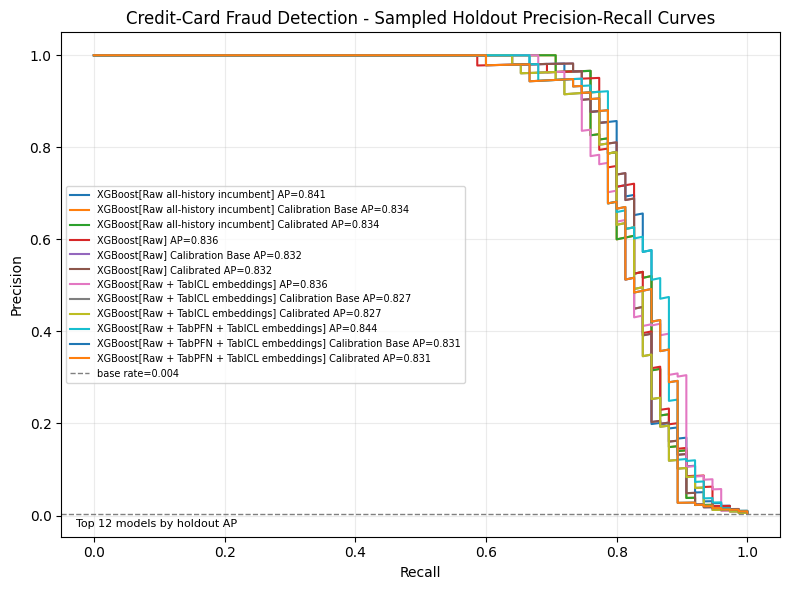

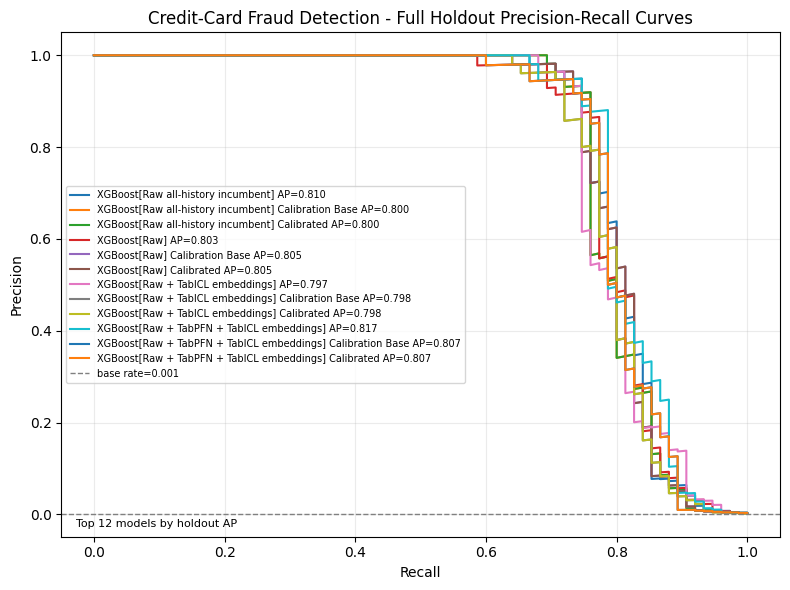

In [11]:
_ = plot_precision_recall_curves(
    fraud_predictions,
    y_by_holdout,
    holdout_name="sampled",
    title="Credit-Card Fraud Detection - Sampled Holdout Precision-Recall Curves",
    output_path=ARTIFACT_DIR / "fraud_precision_recall_curves_sampled.png",
)

_ = plot_precision_recall_curves(
    fraud_predictions,
    y_by_holdout,
    holdout_name="full",
    title="Credit-Card Fraud Detection - Full Holdout Precision-Recall Curves",
    output_path=ARTIFACT_DIR / "fraud_precision_recall_curves_full.png",
)


### What the Precision-Recall Curves Show

The precision-recall curves compare the strongest classical production-style scorers under different feature sets. The important read is whether adding TabPFN and/or TabICL embeddings moves the XGBoost curve upward on the full holdout.

The dashed baseline is near zero because fraud is rare. This is why Average Precision and alert-budget metrics are more informative than plain accuracy for this workflow.


## 9. Runtime vs Average Precision

These plots make the practical tradeoff visible: model quality versus workflow time. The dummy baseline is excluded, and the plot is limited to the strongest rows so the labels remain readable.

For raw feature models, workflow time is downstream fit/search, optional calibration, and prediction. For embedding-enhanced models, workflow time also includes the shared offline TabPFN/TabICL embedding preparation cost. If multiple downstream models reuse one embedding table, count that shared preparation cost once at the pipeline level.


,Model,Base Model,Feature Set,Calibration,Holdout,Rows,Average Precision,Brier Score,Shared Feature Prep Seconds,Total Seconds,Workflow Seconds
0,XGBoost[Raw + TabPFN + TabICL embeddings],XGBoost,Raw + TabPFN + TabICL embeddings,none,full,56962,0.8169,0.0004,501.0245,1374.8286,1875.8531
1,XGBoost[Raw all-history incumbent],XGBoost,Raw all-history incumbent,none,full,56962,0.8097,0.0004,0.0000,167.8521,167.8521
2,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,XGBoost,Raw + TabPFN + TabICL embeddings,none_calibration_base,full,56962,0.8069,0.0004,501.0245,1373.4463,1874.4709
3,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,XGBoost,Raw + TabPFN + TabICL embeddings,sigmoid,full,56962,0.8069,0.0005,501.0245,1390.9113,1891.9358
4,XGBoost[Raw] Calibration Base,XGBoost,Raw,none_calibration_base,full,56962,0.8047,0.0004,0.0000,140.8165,140.8165
5,XGBoost[Raw] Calibrated,XGBoost,Raw,sigmoid,full,56962,0.8047,0.0004,0.0000,141.6307,141.6307
6,XGBoost[Raw],XGBoost,Raw,none,full,56962,0.8034,0.0004,0.0000,140.9872,140.9872
7,XGBoost[Raw all-history incumbent] Calibrated,XGBoost,Raw all-history incumbent,sigmoid,full,56962,0.7997,0.0004,0.0000,168.4397,168.4397
8,XGBoost[Raw all-history incumbent] Calibration...,XGBoost,Raw all-history incumbent,none_calibration_base,full,56962,0.7997,0.0004,0.0000,167.6693,167.6693
9,XGBoost[Raw + TabICL embeddings] Calibration Base,XGBoost,Raw + TabICL embeddings,none_calibration_base,full,56962,0.7978,0.0004,124.4420,1023.4668,1147.9087


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/runtime_ap_summary.csv
Saved tabpfn_tabicl_fraud_detection_20260505_outputs/fraud_runtime_vs_average_precision_sampled.png
Saved tabpfn_tabicl_fraud_detection_20260505_outputs/fraud_runtime_vs_average_precision_full.png


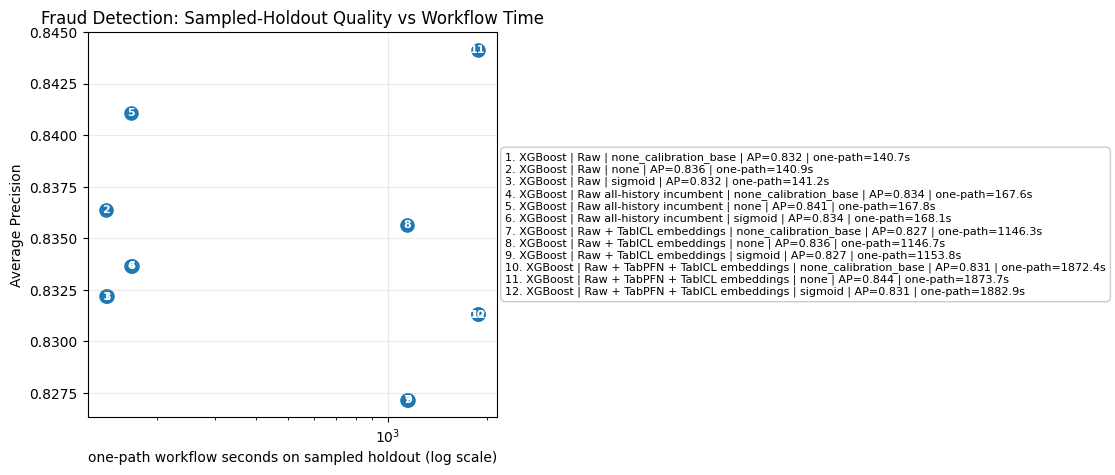

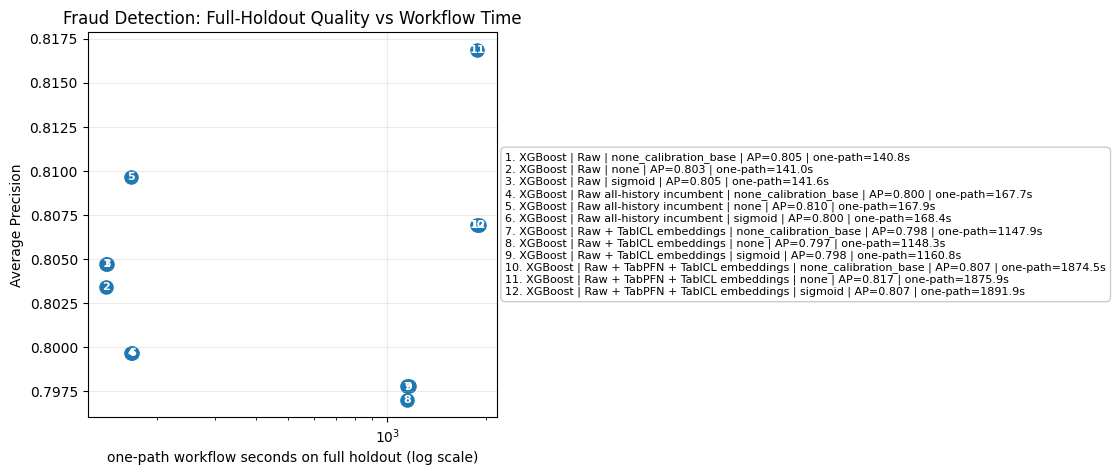

In [12]:
runtime_ap_summary = (
    fraud_summary.loc[
        (fraud_summary["Base Model"] != "Dummy")
        & fraud_summary["Average Precision"].notna()
        & fraud_summary["Workflow Seconds"].notna(),
        ["Model", "Base Model", "Feature Set", "Calibration", "Holdout", "Rows", "Average Precision", "Brier Score", "Shared Feature Prep Seconds", "Total Seconds", "Workflow Seconds"],
    ]
    .sort_values(["Holdout", "Average Precision"], ascending=[True, False])
    .reset_index(drop=True)
)

display(runtime_ap_summary.round(4))
save_artifact_table(runtime_ap_summary, "runtime_ap_summary.csv")


def plot_runtime_vs_ap(summary, holdout_name, output_path):
    plot_df = summary[summary["Holdout"] == holdout_name].copy()
    plot_df = plot_df.sort_values("Average Precision", ascending=False).head(RUNTIME_PLOT_MAX_MODELS)
    plot_df = plot_df.sort_values("Workflow Seconds").reset_index(drop=True)

    if len(plot_df) == 0:
        print(f"No successful {holdout_name}-holdout model results to plot.")
        return None

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(plot_df["Workflow Seconds"], plot_df["Average Precision"], s=90)

    for idx, row in plot_df.iterrows():
        ax.annotate(
            str(idx + 1),
            (row["Workflow Seconds"], row["Average Precision"]),
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
            fontsize=8,
        )

    legend_text = "\n".join(
        f"{idx + 1}. {row['Base Model']} | {row['Feature Set']} | {row['Calibration']} | AP={row['Average Precision']:.3f} | one-path={row['Workflow Seconds']:.1f}s"
        for idx, row in plot_df.iterrows()
    )
    ax.text(
        1.02,
        0.5,
        legend_text,
        transform=ax.transAxes,
        va="center",
        ha="left",
        fontsize=8,
        bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "edgecolor": "0.8"},
    )

    ax.set_xscale("log")
    ax.set_xlabel(f"one-path workflow seconds on {holdout_name} holdout (log scale)")
    ax.set_ylabel("Average Precision")
    ax.set_title(f"Fraud Detection: {holdout_name.title()}-Holdout Quality vs Workflow Time")
    ax.grid(alpha=0.25)
    fig.subplots_adjust(right=0.58)
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Saved {output_path}")
    return fig


_ = plot_runtime_vs_ap(
    runtime_ap_summary,
    holdout_name="sampled",
    output_path=ARTIFACT_DIR / "fraud_runtime_vs_average_precision_sampled.png",
)

_ = plot_runtime_vs_ap(
    runtime_ap_summary,
    holdout_name="full",
    output_path=ARTIFACT_DIR / "fraud_runtime_vs_average_precision_full.png",
)


### What the Runtime Comparison Means

The runtime plot asks what changes when the production scorer remains classical and an offline TFM representation step is added upstream.

If embedding-enhanced rows improve full-holdout AP, top-alert recall, or calibration enough, the added representation step may be worth considering for batch-scored workflows. If not, the classical raw-feature workflow is the more deployable answer. The shared embedding-preparation column is especially important when comparing many downstream models from the same embedding table.


## 10. Alert-Budget and Operating-Point View

Fraud teams often cannot investigate every transaction. This section converts model scores into operating decisions: top-percentage alert budgets, fixed alert counts, and the number of alerts needed to reach target recall. This is more deployment-like than ranking models only by Average Precision.


In [13]:
def alert_budget_table(y_true, y_proba, alert_rates=(0.005, 0.01, 0.02, 0.05)):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba)
    order = np.argsort(-y_proba)
    total_positives = max(y_true.sum(), 1)

    rows = []
    for rate in alert_rates:
        k = max(1, int(np.ceil(rate * len(y_true))))
        selected = order[:k]
        positives_found = int(y_true[selected].sum())
        rows.append(
            {
                "alert_type": "top_rate",
                "alert_value": rate,
                "alerts": k,
                "frauds_found": positives_found,
                "precision": positives_found / k,
                "recall": positives_found / total_positives,
            }
        )

    return pd.DataFrame(rows)


def fixed_alert_count_table(y_true, y_proba, alert_counts=(100, 250, 500, 1000)):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba)
    order = np.argsort(-y_proba)
    total_positives = max(y_true.sum(), 1)

    rows = []
    for k in alert_counts:
        k = min(k, len(y_true))
        selected = order[:k]
        positives_found = int(y_true[selected].sum())
        rows.append(
            {
                "alert_type": "top_count",
                "alert_value": k,
                "alerts": k,
                "frauds_found": positives_found,
                "precision": positives_found / k,
                "recall": positives_found / total_positives,
            }
        )

    return pd.DataFrame(rows)


def target_recall_table(y_true, y_proba, target_recalls=(0.80, 0.90)):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba)
    order = np.argsort(-y_proba)
    sorted_true = y_true[order]
    cumulative_frauds = np.cumsum(sorted_true)
    total_positives = max(y_true.sum(), 1)

    rows = []
    for target_recall in target_recalls:
        required_frauds = target_recall * total_positives
        k = int(np.searchsorted(cumulative_frauds, required_frauds, side="left") + 1)
        k = min(k, len(y_true))
        threshold = y_proba[order[k - 1]]
        positives_found = int(cumulative_frauds[k - 1])
        rows.append(
            {
                "target_recall": target_recall,
                "threshold": threshold,
                "alerts": k,
                "frauds_found": positives_found,
                "precision": positives_found / k,
                "recall": positives_found / total_positives,
            }
        )

    return pd.DataFrame(rows)


def all_operating_tables(predictions, y_by_holdout):
    budget_rows = []
    recall_rows = []

    for (model_name, holdout_name), y_proba in predictions.items():
        y_true = y_by_holdout[holdout_name]

        budget_table = pd.concat(
            [
                alert_budget_table(y_true, y_proba),
                fixed_alert_count_table(y_true, y_proba),
            ],
            ignore_index=True,
        )
        budget_table.insert(0, "Holdout", holdout_name)
        budget_table.insert(0, "Model", model_name)
        budget_rows.append(budget_table)

        recall_table = target_recall_table(y_true, y_proba)
        recall_table.insert(0, "Holdout", holdout_name)
        recall_table.insert(0, "Model", model_name)
        recall_rows.append(recall_table)

    return pd.concat(budget_rows, ignore_index=True), pd.concat(recall_rows, ignore_index=True)


if not fraud_predictions:
    print("No successful model predictions available for operating-point analysis.")
else:
    alert_summary, recall_summary = all_operating_tables(fraud_predictions, y_by_holdout)
    display(alert_summary.round(4))
    display(recall_summary.round(4))
    save_artifact_table(alert_summary, "alert_summary.csv")
    save_artifact_table(recall_summary, "target_recall_summary.csv")


,Model,Holdout,alert_type,alert_value,alerts,frauds_found,precision,recall
0,Dummy[Raw],sampled,top_rate,0.005,101,0,0.0000,0.0000
1,Dummy[Raw],sampled,top_rate,0.010,201,0,0.0000,0.0000
2,Dummy[Raw],sampled,top_rate,0.020,402,0,0.0000,0.0000
3,Dummy[Raw],sampled,top_rate,0.050,1004,4,0.0040,0.0533
4,Dummy[Raw],sampled,top_count,100.000,100,0,0.0000,0.0000
...,...,...,...,...,...,...,...,...
251,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,full,top_rate,0.050,2849,67,0.0235,0.8933
252,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,full,top_count,100.000,100,59,0.5900,0.7867
253,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,full,top_count,250.000,250,64,0.2560,0.8533
254,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,full,top_count,500.000,500,66,0.1320,0.8800


,Model,Holdout,target_recall,threshold,alerts,frauds_found,precision,recall
0,Dummy[Raw],sampled,0.8,0.0015,12430,60,0.0048,0.8000
1,Dummy[Raw],sampled,0.9,0.0015,16981,68,0.0040,0.9067
2,Dummy[Raw],full,0.8,0.0015,35260,60,0.0017,0.8000
3,Dummy[Raw],full,0.9,0.0015,48140,68,0.0014,0.9067
4,XGBoost[Raw all-history incumbent],sampled,0.8,0.0594,70,60,0.8571,0.8000
...,...,...,...,...,...,...,...,...
59,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,full,0.9,0.0000,6902,68,0.0099,0.9067
60,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,sampled,0.8,0.0004,88,60,0.6818,0.8000
61,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,sampled,0.9,0.0003,2431,68,0.0280,0.9067
62,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,full,0.8,0.0004,119,60,0.5042,0.8000


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/alert_summary.csv
Saved tabpfn_tabicl_fraud_detection_20260505_outputs/target_recall_summary.csv


### What the alert-budget tables mean

This is the most deployment-like view in the notebook. Fraud teams usually operate review queues, not abstract model scores. The target-recall table shows how many transactions would need to be reviewed to recover a chosen fraction of fraud cases.

When headline Average Precision values are close, compare the alert counts needed at the same target recall and the frauds found at the same alert budget. A model with similar AP can still be operationally better if it finds the same fraud volume with fewer review slots.

The thresholds in this table are score cutoffs, not guaranteed calibrated fraud probabilities. Treat them as operating-point choices for ranking and queue construction unless probability calibration has been validated separately. The CSV artifacts contain the full tables, so the analysis does not depend on truncated notebook display output.


## 11. Calibration Diagnostics

Fraud scores are often used for ranking, but operational thresholds depend on probability behavior. Brier score is reported in the main metric table. The calibrated classical variants use a separate full-prevalence calibration window rather than the validation window used for model selection.

The plots below are zoomed into the rare-event probability range. A full 0-1 calibration plot is not very useful here because almost every meaningful point sits near zero. Public fraud datasets often provide limited positive examples in later windows, so these curves are diagnostics for model behavior, not a production calibration certificate.


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/fraud_calibration_curves_sampled.png
Saved tabpfn_tabicl_fraud_detection_20260505_outputs/fraud_calibration_curves_full.png


,Model,Family,Calibration,Holdout,Average Precision,Brier Score,Log Loss,ECE Quantile 10
0,XGBoost[Raw + TabPFN + TabICL embeddings],classical,none,full,0.8169,0.0004,0.0025,0.0003
1,XGBoost[Raw all-history incumbent],classical_incumbent,none,full,0.8097,0.0004,0.0028,0.0001
2,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,classical_calibration_base,none_calibration_base,full,0.8069,0.0004,0.0028,0.0003
3,XGBoost[Raw + TabPFN + TabICL embeddings] Cali...,classical_calibrated,sigmoid,full,0.8069,0.0005,0.0034,0.0005
4,XGBoost[Raw] Calibration Base,classical_calibration_base,none_calibration_base,full,0.8047,0.0004,0.0028,0.0002
5,XGBoost[Raw] Calibrated,classical_calibrated,sigmoid,full,0.8047,0.0004,0.0033,0.0004
6,XGBoost[Raw],classical,none,full,0.8034,0.0004,0.0028,0.0002
7,XGBoost[Raw all-history incumbent] Calibrated,classical_incumbent_calibrated,sigmoid,full,0.7997,0.0004,0.0032,0.0003
8,XGBoost[Raw all-history incumbent] Calibration...,classical_incumbent_calibration_base,none_calibration_base,full,0.7997,0.0004,0.0031,0.0002
9,XGBoost[Raw + TabICL embeddings] Calibration Base,classical_calibration_base,none_calibration_base,full,0.7978,0.0004,0.0027,0.0004


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/calibration_quality_view.csv
Saved tabpfn_tabicl_fraud_detection_20260505_outputs/reliability_summary.csv


,Model,Holdout,bin,rows,fraud_rows,score_min,score_max,mean_score,observed_fraud_rate,abs_calibration_error
70,XGBoost[Raw all-history incumbent] Calibrated,full,1,5697,0,0.000255,0.000255,0.000255,0.000000,0.000255
71,XGBoost[Raw all-history incumbent] Calibrated,full,2,5697,0,0.000255,0.000255,0.000255,0.000000,0.000255
72,XGBoost[Raw all-history incumbent] Calibrated,full,3,5696,0,0.000255,0.000255,0.000255,0.000000,0.000255
73,XGBoost[Raw all-history incumbent] Calibrated,full,4,5696,0,0.000255,0.000255,0.000255,0.000000,0.000255
74,XGBoost[Raw all-history incumbent] Calibrated,full,5,5696,1,0.000255,0.000255,0.000255,0.000176,0.000079
75,XGBoost[Raw all-history incumbent] Calibrated,full,6,5696,0,0.000255,0.000255,0.000255,0.000000,0.000255
76,XGBoost[Raw all-history incumbent] Calibrated,full,7,5696,1,0.000255,0.000255,0.000255,0.000176,0.000079
77,XGBoost[Raw all-history incumbent] Calibrated,full,8,5696,2,0.000255,0.000255,0.000255,0.000351,0.000096
78,XGBoost[Raw all-history incumbent] Calibrated,full,9,5696,2,0.000255,0.000255,0.000255,0.000351,0.000096
79,XGBoost[Raw all-history incumbent] Calibrated,full,10,5696,69,0.000255,0.969218,0.010995,0.012114,0.001119


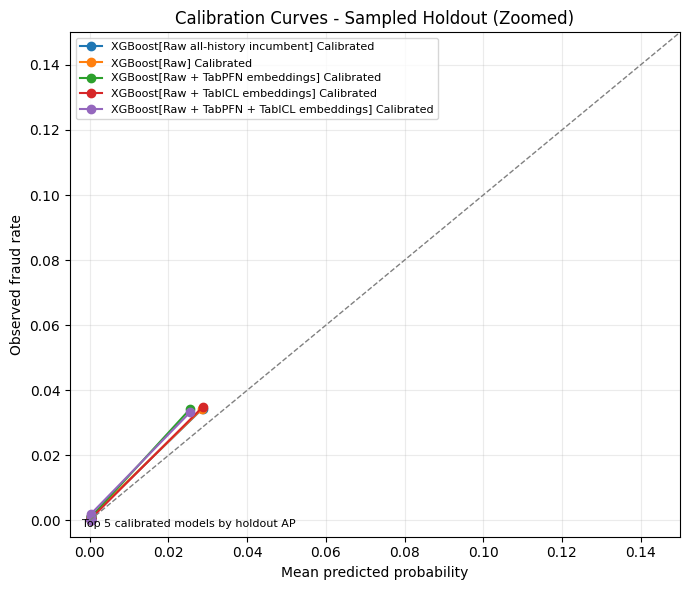

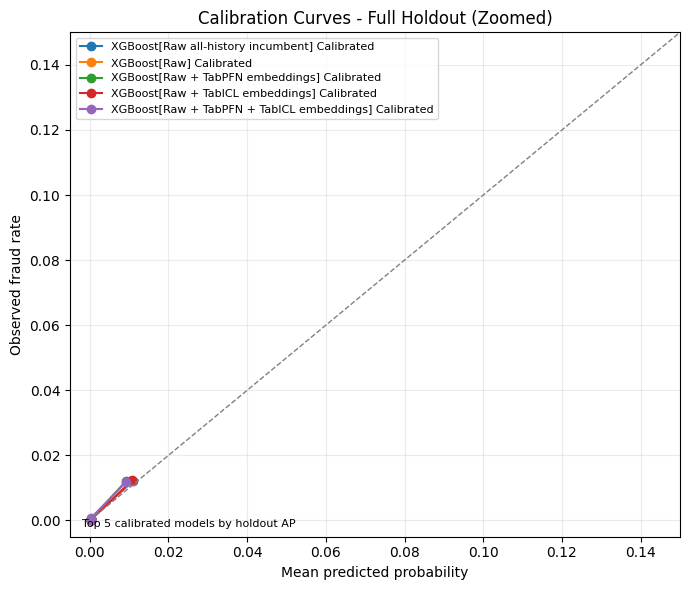

In [14]:
def selected_calibration_models(summary, holdout_name, max_models=CALIBRATION_PLOT_MAX_MODELS):
    calibrated = summary.loc[
        (summary["Holdout"] == holdout_name)
        & (summary["Calibration"] == "sigmoid")
        & summary["Average Precision"].notna()
        & (summary["Base Model"] != "Dummy")
    ].sort_values("Average Precision", ascending=False)
    if len(calibrated) > 0:
        return set(calibrated.head(max_models)["Model"]), "calibrated"

    fallback = summary.loc[
        (summary["Holdout"] == holdout_name)
        & summary["Average Precision"].notna()
        & (summary["Base Model"] != "Dummy")
    ].sort_values("Average Precision", ascending=False)
    return set(fallback.head(max_models)["Model"]), "available"


def plot_calibration_curves(predictions, y_by_holdout, holdout_name, output_path=None, max_axis=0.15):
    fig, ax = plt.subplots(figsize=(7, 6))
    plotted = False
    selected_models, selection_label = selected_calibration_models(fraud_summary, holdout_name) if "fraud_summary" in globals() else (None, "available")

    for (model_name, prediction_holdout), y_proba in predictions.items():
        if prediction_holdout != holdout_name:
            continue
        if selected_models is not None and model_name not in selected_models:
            continue
        y_true = y_by_holdout[holdout_name]
        prob_true, prob_pred = calibration_curve(
            y_true,
            y_proba,
            n_bins=10,
            strategy="quantile",
        )
        ax.plot(prob_pred, prob_true, marker="o", label=model_name)
        plotted = True

    if not plotted:
        print(f"No successful model predictions to plot for holdout={holdout_name}.")
        return None

    ax.plot([0, max_axis], [0, max_axis], color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(-0.005, max_axis)
    ax.set_ylim(-0.005, max_axis)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed fraud rate")
    ax.set_title(f"Calibration Curves - {holdout_name.title()} Holdout (Zoomed)")
    ax.legend(fontsize=8)
    if selected_models is not None:
        ax.text(0.02, 0.02, f"Top {len(selected_models)} {selection_label} models by holdout AP", transform=ax.transAxes, fontsize=8)
    ax.grid(alpha=0.25)
    plt.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=160, bbox_inches="tight")
        print(f"Saved {output_path}")

    return fig


_ = plot_calibration_curves(
    fraud_predictions,
    y_by_holdout,
    holdout_name="sampled",
    output_path=ARTIFACT_DIR / "fraud_calibration_curves_sampled.png",
)

_ = plot_calibration_curves(
    fraud_predictions,
    y_by_holdout,
    holdout_name="full",
    output_path=ARTIFACT_DIR / "fraud_calibration_curves_full.png",
)

calibration_quality_view = (
    fraud_summary.loc[
        fraud_summary["Average Precision"].notna(),
        [
            "Model",
            "Family",
            "Calibration",
            "Holdout",
            "Average Precision",
            "Brier Score",
            "Log Loss",
            "ECE Quantile 10",
        ],
    ]
    .sort_values(["Holdout", "Average Precision"], ascending=[True, False])
    .reset_index(drop=True)
)


def all_reliability_tables(predictions, y_by_holdout, n_bins=10):
    rows = []
    for (model_name, holdout_name), y_proba in predictions.items():
        table = calibration_bin_table(y_by_holdout[holdout_name], y_proba, n_bins=n_bins)
        table.insert(0, "Holdout", holdout_name)
        table.insert(0, "Model", model_name)
        rows.append(table)

    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


reliability_summary = all_reliability_tables(fraud_predictions, y_by_holdout, n_bins=10)

display(calibration_quality_view.round(4))
save_artifact_table(calibration_quality_view, "calibration_quality_view.csv")

if len(reliability_summary) > 0:
    save_artifact_table(reliability_summary, "reliability_summary.csv")
    selected_full_models, _ = selected_calibration_models(fraud_summary, "full")
    reliability_display = reliability_summary.loc[
        (reliability_summary["Holdout"] == "full")
        & (reliability_summary["Model"].isin(selected_full_models))
    ]
    display(reliability_display.round(6))


### What the Calibration Results Mean

The calibration view separates ranking quality from probability quality for the classical workflow. The embedding-enhanced variants can improve ranking while still needing calibration before their scores are treated as probabilities.

Read the calibrated rows against their matching `Calibration Base` rows. That isolates the effect of sigmoid calibration from the effect of withholding the calibration window from the base fit. The ordinary uncalibrated `none` rows still answer the ranking question for models refit on all pre-holdout labels.

For a production-style fraud workflow, the useful read is not only which feature set has the best Average Precision. Check whether the calibrated raw or embedding-enhanced model gives a better combination of AP, Brier score, log loss, expected calibration error, reliability-bin behavior, and alert-budget recall on the full holdout.


## 12. Leakage and Reuse Checklist

This dataset is anonymized, so some production checks cannot be fully resolved. The point of this section is to make the reusable workflow explicit: before trusting any fraud result, check chronological ordering, feature availability, duplicates, target leakage, and entity-level leakage.

Rows can share the same `Time` value, so the split check below is about chronological ordering by row position after sorting, not a claim that boundary timestamp values are strictly separated. Since `Time` is excluded from model features, equal boundary timestamps are a split-design caveat rather than feature leakage.

The duplicate-row check reports exact duplicate rows and duplicate model-feature rows. The model-feature check ignores `Time` and `Class`, matching what the models see when `USE_TIME_AS_FEATURE = False`. In a real fraud project, repeated-looking transactions may be legitimate recurring payments, retries, or duplicated records. This public dataset does not expose enough raw identifiers to fully adjudicate them, so the notebook reports the issue explicitly.


In [15]:
window_labels = pd.Series(index=df.index, dtype="object")
window_labels.iloc[:embedding_context_end_idx] = "embedding_context"
window_labels.iloc[embedding_context_end_idx:train_end_idx] = "train"
window_labels.iloc[train_end_idx:validation_end_idx] = "validation"
window_labels.iloc[validation_end_idx:calibration_end_idx] = "calibration"
window_labels.iloc[calibration_end_idx:] = "test"


def summarize_duplicate_groups(group_hashes, labels, class_values):
    duplicate_frame = pd.DataFrame(
        {
            "duplicate_group": group_hashes,
            "window": labels,
            "Class": class_values.astype(int),
        }
    )
    group_sizes = duplicate_frame.groupby("duplicate_group").size()
    repeated_group_ids = group_sizes[group_sizes > 1].index
    duplicate_detail = duplicate_frame[duplicate_frame["duplicate_group"].isin(repeated_group_ids)].copy()

    if len(duplicate_detail) == 0:
        duplicate_group_summary = pd.DataFrame(
            columns=["duplicate_group", "rows", "windows", "fraud_rows"]
        )
        return duplicate_detail, duplicate_group_summary, 0

    duplicate_group_summary = (
        duplicate_detail.groupby("duplicate_group")
        .agg(rows=("Class", "size"), windows=("window", "nunique"), fraud_rows=("Class", "sum"))
        .reset_index()
    )
    cross_window_groups = int((duplicate_group_summary["windows"] > 1).sum())
    return duplicate_detail, duplicate_group_summary, cross_window_groups


exact_duplicate_group = pd.util.hash_pandas_object(df, index=False)
feature_duplicate_group = pd.util.hash_pandas_object(df[feature_columns], index=False)

exact_duplicate_detail, exact_duplicate_group_summary, exact_cross_window_groups = summarize_duplicate_groups(
    exact_duplicate_group,
    window_labels,
    df[target_column],
)
feature_duplicate_detail, feature_duplicate_group_summary, feature_cross_window_groups = summarize_duplicate_groups(
    feature_duplicate_group,
    window_labels,
    df[target_column],
)

exact_duplicate_rows = int(len(exact_duplicate_detail))
feature_duplicate_rows = int(len(feature_duplicate_detail))

feature_cross_window_fraud_rows = 0
if len(feature_duplicate_group_summary) > 0:
    feature_cross_window_ids = feature_duplicate_group_summary.loc[
        feature_duplicate_group_summary["windows"] > 1,
        "duplicate_group",
    ]
    feature_cross_window_fraud_rows = int(
        feature_duplicate_detail.loc[
            feature_duplicate_detail["duplicate_group"].isin(feature_cross_window_ids),
            "Class",
        ].sum()
    )

duplicate_diagnostics = pd.DataFrame(
    [
        {"metric": "exact_duplicate_rows_including_time_and_target", "value": exact_duplicate_rows},
        {"metric": "exact_duplicate_groups_including_time_and_target", "value": len(exact_duplicate_group_summary)},
        {"metric": "exact_duplicate_groups_crossing_time_windows", "value": exact_cross_window_groups},
        {"metric": "model_feature_duplicate_rows", "value": feature_duplicate_rows},
        {"metric": "model_feature_duplicate_groups", "value": len(feature_duplicate_group_summary)},
        {"metric": "model_feature_duplicate_groups_crossing_time_windows", "value": feature_cross_window_groups},
        {"metric": "fraud_rows_inside_cross_window_model_feature_duplicate_groups", "value": feature_cross_window_fraud_rows},
    ]
)
display(duplicate_diagnostics)
save_artifact_table(duplicate_diagnostics, "duplicate_diagnostics.csv")

if exact_duplicate_rows > 0:
    print("Exact duplicate rows by time window and class:")
    exact_duplicate_by_window_and_class = (
        exact_duplicate_detail.groupby(["window", "Class"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={0: "non_fraud_duplicate_rows", 1: "fraud_duplicate_rows"})
        .reset_index()
    )
    display(exact_duplicate_by_window_and_class)
    save_artifact_table(exact_duplicate_by_window_and_class, "exact_duplicate_by_window_and_class.csv")
else:
    print("No exact duplicate rows found when Time and Class are included.")

if feature_duplicate_rows > 0:
    print("Largest duplicate groups based on model features only:")
    largest_model_feature_duplicate_groups = (
        feature_duplicate_group_summary.sort_values(["windows", "rows"], ascending=[False, False])
        .head(10)
        .drop(columns=["duplicate_group"])
    )
    display(largest_model_feature_duplicate_groups)
    save_artifact_table(largest_model_feature_duplicate_groups, "largest_model_feature_duplicate_groups.csv")

    if feature_cross_window_groups > 0:
        print("Model-feature duplicate groups crossing time windows need review:")
        cross_window_model_feature_duplicate_groups = (
            feature_duplicate_group_summary.loc[feature_duplicate_group_summary["windows"] > 1]
            .sort_values(["windows", "rows"], ascending=[False, False])
            .head(10)
            .drop(columns=["duplicate_group"])
        )
        display(cross_window_model_feature_duplicate_groups)
        save_artifact_table(cross_window_model_feature_duplicate_groups, "cross_window_model_feature_duplicate_groups.csv")
    else:
        print("No duplicate model-feature groups cross time windows.")
else:
    print("No duplicate model-feature rows found.")

chronological_split_ordered = (
    embedding_context_period["Time"].max() <= train_period["Time"].min()
    and train_period["Time"].max() <= validation_period["Time"].min()
    and validation_period["Time"].max() <= calibration_period["Time"].min()
    and calibration_period["Time"].max() <= test_period["Time"].min()
)

duplicate_status = "review" if exact_duplicate_rows > 0 or feature_cross_window_groups > 0 else "pass"

leakage_checks = pd.DataFrame(
    [
        {
            "Check": "Target excluded from features",
            "Status": "pass" if target_column not in feature_columns else "fail",
            "Evidence": f"target_column={target_column}; feature_count={len(feature_columns)}",
        },
        {
            "Check": "Time column preserved for temporal split",
            "Status": "pass" if "Time" in df.columns else "fail",
            "Evidence": f"Time range {df['Time'].min():.0f} to {df['Time'].max():.0f}" if "Time" in df.columns else "Time missing",
        },
        {
            "Check": "Time used as model feature",
            "Status": "review" if "Time" in feature_columns else "not_used_as_feature",
            "Evidence": f"USE_TIME_AS_FEATURE={USE_TIME_AS_FEATURE}; Time in feature_columns={'Time' in feature_columns}",
        },
        {
            "Check": "Chronological split order",
            "Status": "pass" if chronological_split_ordered else "review",
            "Evidence": f"sorted by Time before splitting; equal boundary timestamps can occur; context max={embedding_context_period['Time'].max():.0f}, train min={train_period['Time'].min():.0f}, train max={train_period['Time'].max():.0f}, validation min={validation_period['Time'].min():.0f}, validation max={validation_period['Time'].max():.0f}, calibration min={calibration_period['Time'].min():.0f}, calibration max={calibration_period['Time'].max():.0f}, test min={test_period['Time'].min():.0f}",
        },
        {
            "Check": "Duplicate rows and duplicate model-feature rows",
            "Status": duplicate_status,
            "Evidence": f"exact_duplicate_rows={exact_duplicate_rows:,}; exact_cross_window_groups={exact_cross_window_groups:,}; model_feature_duplicate_rows={feature_duplicate_rows:,}; model_feature_cross_window_groups={feature_cross_window_groups:,}",
        },
        {
            "Check": "Future aggregate features",
            "Status": "unknown",
            "Evidence": "V1-V28 are anonymized PCA-style features; raw feature lineage is not available in this public dataset.",
        },
        {
            "Check": "Entity-level leakage / customer grouping",
            "Status": "unknown",
            "Evidence": "No customer/card/account identifier is available, so group-based splitting cannot be tested here.",
        },
        {
            "Check": "Label delay / chargeback availability",
            "Status": "unknown",
            "Evidence": "The public dataset does not expose when the fraud label became known.",
        },
    ]
)

display(leakage_checks)
save_artifact_table(leakage_checks, "leakage_checks.csv")


,metric,value
0,exact_duplicate_rows_including_time_and_target,1854
1,exact_duplicate_groups_including_time_and_target,773
2,exact_duplicate_groups_crossing_time_windows,0
3,model_feature_duplicate_rows,14293
4,model_feature_duplicate_groups,5149
5,model_feature_duplicate_groups_crossing_time_w...,2178
6,fraud_rows_inside_cross_window_model_feature_d...,0


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/duplicate_diagnostics.csv
Exact duplicate rows by time window and class:


Class,window,non_fraud_duplicate_rows,fraud_duplicate_rows
0,calibration,206,0
1,embedding_context,415,0
2,test,390,2
3,train,671,30
4,validation,140,0


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/exact_duplicate_by_window_and_class.csv
Largest duplicate groups based on model features only:


,rows,windows,fraud_rows
4643,53,4,0
3508,48,4,0
1102,35,4,0
496,30,4,0
1162,27,4,0
2231,25,4,0
231,21,4,0
3091,20,4,0
4180,18,4,0
2923,16,4,0


...

,rows,windows,fraud_rows
4643,53,4,0
3508,48,4,0
1102,35,4,0
496,30,4,0
1162,27,4,0
2231,25,4,0
231,21,4,0
3091,20,4,0
4180,18,4,0
2923,16,4,0


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/cross_window_model_feature_duplicate_groups.csv


,Check,Status,Evidence
0,Target excluded from features,pass,target_column=Class; feature_count=29
1,Time column preserved for temporal split,pass,Time range 0 to 172792
2,Time used as model feature,not_used_as_feature,USE_TIME_AS_FEATURE=False; Time in feature_col...
3,Chronological split order,pass,sorted by Time before splitting; equal boundar...
4,Duplicate rows and duplicate model-feature rows,review,"exact_duplicate_rows=1,854; exact_cross_window..."
5,Future aggregate features,unknown,V1-V28 are anonymized PCA-style features; raw ...
6,Entity-level leakage / customer grouping,unknown,No customer/card/account identifier is availab...
7,Label delay / chargeback availability,unknown,The public dataset does not expose when the fr...


Saved tabpfn_tabicl_fraud_detection_20260505_outputs/leakage_checks.csv


PosixPath('tabpfn_tabicl_fraud_detection_20260505_outputs/leakage_checks.csv')

### What the leakage checklist means

This checklist is not a substitute for a production leakage review. It is the public-dataset version of that review.

The useful questions are whether the target is excluded, whether the chronological split is ordered, whether `Time` is intentionally included or excluded as a feature, and whether duplicate rows cross time windows. Exact duplicates that do not cross windows are less concerning than duplicate model-feature rows that appear in several windows, but the public dataset does not expose customer, card, merchant, device, or label-availability fields. Those missing fields are why the notebook reports several production leakage checks as `unknown` rather than pretending they passed.


## 13. Time Feature Policy

The default run sets `USE_TIME_AS_FEATURE = False`. `Time` is still essential for temporal splitting, but the model features exclude it so the raw and embedding-enhanced comparisons do not depend directly on position in this public dataset.

Sensitivity analysis: rerun the notebook with `USE_TIME_AS_FEATURE = True` and compare the full-holdout, reliability, and alert-budget tables. Treat any large gain from `Time` as a signal to investigate whether the feature would be available, stable, and policy-acceptable in the intended production setting.
